# Notebook 02 — Baseline Regression Experiments with SageMaker MLflow App

**Module:** ITI113 Machine Learning & Operations
**Focus Area:** B — Model Development + C — MLOps (Experiment Tracking)
**Project:** Airbnb *fair advertised nightly rate* — **regression** on `log_price`
**Estimated Runtime:** 10–20 minutes

---

## What this notebook does

This is the AWS-native experiments notebook. It uses the **SageMaker MLflow App / Serverless MLflow** created in `01A_setup_sagemaker_mlflow_app_(with_team_tags).ipynb` and the processed matrices produced by `01_eda_and_feature_engineering.ipynb`.

1. Connects to the team's SageMaker MLflow App and **validates the `TeamId` tag** before logging anything
2. Carves a **held-out validation split from the training data** and defines a **regression metric suite** (MAE, RMSE, R², MAPE) that is honest about the multi-currency target
3. **Run 1 — Ridge regression**: the interpretable statistical baseline
4. **Run 2 — Random Forest** and **Run 3 — Histogram Gradient Boosting**: the ensemble-tree comparison models
5. **Run 4 — Hyperparameter tuning** with nested parent/child MLflow runs
6. A **cross-candidate screening pass** (permutation importance on validation) before any winner is crowned
7. Programmatic run comparison **on validation**, a **full-training-set refit of the winner**, a quality gate, and `best_model.json` hand-off for Notebook 03
8. A **regression error-analysis deep dive** on the refit champion: calibration, residuals, per-city decomposition, error-by-price-band, feature importance, and a forensic look at the most extreme mispricings

## The validation protocol, stated once

Notebook 01 produced a train/test split. This notebook splits **train** again, 80/20 stratified by city, into a *fit* portion and a *validation* portion:

| Split | Rows (approx.) | Used for |
|---|---|---|
| **fit** | 64% of all data | training the four candidate models; the tuning grid's CV folds |
| **validation** | 16% of all data | **all model-selection decisions** — which family wins, which hyperparameters win |
| **test** | 20% of all data | **touched exactly once**, by the refit champion, for final reporting |

Candidates log `fit_*` and `val_*` metrics and never see test. Once validation names a winner, that configuration is **refit on the full training set** (fit + validation) and that single run logs `test_*`. This is the same fit → select → refit pattern already used inside Step 7's tuning loop, applied one level up.

The refit matters for more than tidiness: it means the champion is trained on every row Notebook 03 will train on, so the hand-off metrics in `best_model.json` are the ones Notebook 03's consistency proof reproduces.


### One known, bounded contamination

Notebook 01 fitted the preprocessor (imputation medians, `StandardScaler` statistics, the top-K amenity vocabulary, neighbourhood frequencies, the host-count cap, the frozen one-hot levels) on the **whole** training split. The validation portion is carved out of that same training split *after* the fact, so those statistics were computed with the validation rows included. Validation is therefore not perfectly clean.

Three reasons this is documented rather than fixed:

- **Magnitude.** Every statistic is an aggregate over ~223k rows; a single validation row moves a mean by roughly 0.0004%. The induced optimism is orders of magnitude below the spread between candidates.
- **Symmetry.** All candidates receive the identical matrix, so the *ranking* is the only output validation produces is unaffected. Selection uses validation for ordering, not for an absolute performance claim.
- **Test is unaffected.** The preprocessor was never fitted on test rows. Every reported number, the quality gate, and Notebook 03's promotion metrics are clean.

Eliminating it would mean refitting the preprocessor on the fit portion alone, which regenerates the feature matrices and breaks Notebook 01's published contract, Notebook 03's byte-level consistency proof, and the metric assertion that ties the two together. The cost is structural; the benefit is a fourth decimal place on a number used only for ranking. **This paragraph belongs in the model card's limitations section**, which is the point of writing it down.

## Expected setup from Notebook 01A

Notebook 01A created the team MLflow App and saved a local config file that this notebook auto-discovers:

```text
mlflow_app_config_<team_id>.json
mlflow_app_config_<team_id>_<student_id>.json
```


The training data comes from the same team S3 prefix used in Notebook 01. Before logging, this notebook **validates that the selected MLflow App carries `TeamId = TEAM_ID`** — with team-level IAM restriction, using another team's App should fail with 403, and this explicit check catches the mistake even earlier.

> **Prerequisite:** Notebook 01 must have produced `train_features.csv`, `train_labels.csv`, `test_features.csv`, `test_labels.csv` and `preprocessing_artifacts.json` (88-column feature contract, labels carrying `log_price` + raw `price`).

## Install or update required packages *(SageMaker Studio only)*

In [1]:
# %pip install --upgrade "sagemaker>=2,<3" boto3 botocore
# %pip install --upgrade mlflow sagemaker-mlflow

## 0. Configuration

Identical team/course constants as Notebooks 01/01A, plus **MLflow App discovery**: the notebook looks for the config JSON that 01A saved (team-level file first, then student-specific, then any team-matching file) and falls back to a hard-coded ARN only if no file is found. Off SageMaker, it degrades to a local SQLite tracking store (`sqlite:///mlflow_local.db`) so the whole experiment suite — including nested runs and `search_runs` comparison — still works end-to-end.

In [2]:
import os, io, json, glob, time, tempfile, warnings, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from scipy.linalg import LinAlgWarning
warnings.filterwarnings('ignore', category=LinAlgWarning)   # alpha->0 probes on collinear one-hots
sns.set_theme(style='whitegrid', palette='muted')

# ============================================================
# Student / team settings — change only these
# ============================================================
TEAM_ID      = "team14"
STUDENT_ID   = "s1402"
COURSE       = "ITI113"
SEMESTER     = "26S1"
PROJECT_NAME = "airbnb-listings"
REGION       = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

RANDOM_STATE = 42
TARGET       = "log_price"          # log1p of per-city-winsorised advertised price (Notebook 01 6.5)

# ============================================================
# Environment detection: SageMaker vs local
# ============================================================
try:
    import sagemaker, boto3
    session = sagemaker.Session()
    role = sagemaker.get_execution_role()
    LOCAL_MODE = False
    print(f"SageMaker mode | role: {role.split('/')[-1]}")
except Exception:
    LOCAL_MODE = True
    print("SageMaker not available -> LOCAL_MODE (file-based MLflow store, local processed/ data)")

# ============================================================
# MLflow App discovery (config saved by Notebook 01A)
#   1. team-level file    mlflow_app_config_team40.json
#   2. student file       mlflow_app_config_team40_s4001.json
#   3. any team match     mlflow_app_config_team40_*.json
#   4. DEFAULT_MLFLOW_APP_ARN fallback
# Never use another team's ARN — IAM should 403 it, and the
# tag check in 1 refuses it explicitly.
# ============================================================
DEFAULT_MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"   # paste from 01A output if no config file is present

config_candidates = ([Path(f"mlflow_app_config_{TEAM_ID}.json"),
                      Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")]
                     + [Path(p) for p in sorted(glob.glob(f"mlflow_app_config_{TEAM_ID}_*.json"))])

MLFLOW_APP_ARN, MLFLOW_CONFIG_SOURCE = None, None
for cand in config_candidates:
    if cand.exists():
        cfg = json.loads(cand.read_text())
        MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"
        MLFLOW_CONFIG_SOURCE = str(cand)
        break
if MLFLOW_APP_ARN is None and DEFAULT_MLFLOW_APP_ARN:
    MLFLOW_APP_ARN, MLFLOW_CONFIG_SOURCE = DEFAULT_MLFLOW_APP_ARN, "DEFAULT_MLFLOW_APP_ARN"

MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"

if LOCAL_MODE:
    # MLflow >= 3 deprecates the plain filesystem store; SQLite is the recommended local backend
    MLFLOW_TRACKING_URI = "sqlite:///mlflow_local.db"
    MLFLOW_CONFIG_SOURCE = MLFLOW_CONFIG_SOURCE or "local SQLite store (no App needed)"
else:
    if MLFLOW_APP_ARN is None:
        raise RuntimeError("No MLflow App config found. Run Notebook 01A first or set DEFAULT_MLFLOW_APP_ARN.")
    MLFLOW_TRACKING_URI = MLFLOW_APP_ARN

print(f"Team / student : {TEAM_ID} / {STUDENT_ID}")
print(f"Data prefix    : s3://{BUCKET}/{PREFIX}" if not LOCAL_MODE else "Data source    : ./processed/ (Notebook 01 local output)")
print(f"MLflow config  : {MLFLOW_CONFIG_SOURCE}")
print(f"Tracking URI   : {MLFLOW_TRACKING_URI}")
print(f"Experiment     : {MLFLOW_EXPERIMENT}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


SageMaker mode | role: SageMakerExecutionRole-ITI113-Team14
Team / student : team14 / s1402
Data prefix    : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings
MLflow config  : DEFAULT_MLFLOW_APP_ARN
Tracking URI   : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment     : ITI113/team14/Experiment1


## 1. Connect to the MLflow App — with team-tag safety check

The classroom restricts each team's IAM role to MLflow Apps tagged with its own `TeamId` (`aws:ResourceTag/TeamId = team40`). Before a single byte is logged, this cell fetches the App's tags and refuses to continue if the tag doesn't match `TEAM_ID` so a copy-pasted ARN from another team fails *loudly here* rather than silently polluting (or 403-ing halfway through) someone else's experiment history. 

In [3]:
import mlflow
import mlflow.sklearn
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

if not LOCAL_MODE:
    sm_client = boto3.client("sagemaker", region_name=REGION)
    try:
        tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
        mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
        print("MLflow App tags:")
        for k, v in mlflow_app_tags.items():
            print(f"  {k}: {v}")
        app_team_id = mlflow_app_tags.get("TeamId")
        if app_team_id != TEAM_ID:
            raise PermissionError(
                f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
                "Do not log to another team's MLflow App.")
        print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")
    except Exception:
        print("[ERROR] Could not validate the MLflow App team tag. Either the ARN belongs to another "
              "team (IAM should deny it), the App was created without tags (rerun 01A), or this role "
              "lacks sagemaker:ListTags.")
        raise
else:
    print("[SKIP] LOCAL_MODE — no SageMaker App to tag-check; using local SQLite store.")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE, "semester": SEMESTER,
    "team_id": TEAM_ID, "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "tracking_backend": "local_sqlite" if LOCAL_MODE else "sagemaker_mlflow_app",
    "notebook": "02_baseline_comparison_and_error_analysis",
    "task_type": "regression",
}
print(f"MLflow {mlflow.__version__} connected | experiment: {MLFLOW_EXPERIMENT}")

MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-bigthb6rme9d
  ProjectName: airbnb-listings
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-bigthb6rme9d/team14-shared-powered
  Course: ITI113
  TeamId: team14
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s1402
[OK] MLflow App tag TeamId=team14 matches notebook TEAM_ID=team14


MLflow 3.13.0 connected | experiment: ITI113/team14/Experiment1


## Presigned MLflow App UI links

MLflow's own printed links are not presigned and will fail with a session error. These helpers mint fresh presigned URLs and deep-link to an experiment or run. **A presigned URL is a credential — do not put one in the report.**

In [4]:
# ================================================================
# 0B. Presigned MLflow App UI links
# ----------------------------------------------------------------
# MLflow prints generic links like https://mlflow.sagemaker.<region>.app.aws/#/...
# Those are NOT presigned and will show a permission/session error. Generate a
# fresh presigned URL instead and append the UI route as a fragment.
#
# SECURITY: a presigned URL is a CREDENTIAL. Anyone holding it can act as this
# execution role inside the MLflow App until it expires. Do not paste one into
# the report, a screenshot, Slack, or a git commit. Cite the ARN plus the
# experiment/run IDs instead -- those are safe identifiers -- and regenerate a
# live link at demo time.
# ================================================================
if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — tracking URI is sqlite:///mlflow_local.db, which has no "
          "MLflow App UI. Presigned links apply only to the SageMaker MLflow App.")
else:
    import botocore

    # ExpiresInSeconds  = how long this link stays redeemable (short by design)
    # SessionExpiration = how long the resulting UI session lasts once opened
    MLFLOW_URL_EXPIRES_IN = 300
    MLFLOW_SESSION_DURATION = 3600

    def create_mlflow_app_presigned_url(fragment: str = "") -> str:
        """Return a presigned MLflow App URL, optionally deep-linked to a UI route."""
        kwargs = dict(Arn=MLFLOW_APP_ARN,
                      ExpiresInSeconds=MLFLOW_URL_EXPIRES_IN,
                      SessionExpirationDurationInSeconds=MLFLOW_SESSION_DURATION)
        try:
            resp = sm_client.create_presigned_mlflow_app_url(**kwargs)
        except botocore.exceptions.ParamValidationError:
            # Older botocore may not accept the expiry parameters — fall back to defaults.
            resp = sm_client.create_presigned_mlflow_app_url(Arn=MLFLOW_APP_ARN)

        base = resp.get("AuthorizedUrl") or resp.get("Url")
        if not base:
            raise RuntimeError(f"No AuthorizedUrl/Url in response: {resp}")

        base = base.split("#", 1)[0]          # drop any fragment before adding ours
        return base + "#" + fragment.lstrip("#") if fragment else base

    def print_mlflow_presigned_links(experiment_id=None, run_id=None, label=""):
        """Print presigned links for an experiment and (optionally) a specific run."""
        if label:
            print(f"--- {label} ---")
        if experiment_id is None:
            print(create_mlflow_app_presigned_url())
            return
        print("Experiment:")
        print("  " + create_mlflow_app_presigned_url(f"/experiments/{experiment_id}"))
        if run_id:
            print("Run:")
            print("  " + create_mlflow_app_presigned_url(
                f"/experiments/{experiment_id}/runs/{run_id}"))
        print(f"(redeemable for {MLFLOW_URL_EXPIRES_IN}s; "
              f"session lasts {MLFLOW_SESSION_DURATION}s — regenerate when stale)")

    # Resolve the experiment id for the experiment this notebook is writing to
    _exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    MLFLOW_EXPERIMENT_ID = _exp.experiment_id if _exp else None

    print(f"MLflow App ARN : {MLFLOW_APP_ARN}")
    print(f"Experiment     : {MLFLOW_EXPERIMENT} (id {MLFLOW_EXPERIMENT_ID})")
    # print(f"Champion run   : {BEST['best_run_id']}\n")
    print_mlflow_presigned_links(MLFLOW_EXPERIMENT_ID,
                                label="Notebook 02 champion")


MLflow App ARN : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment     : ITI113/team14/Experiment1 (id 1)
--- Notebook 02 champion ---
Experiment:


  https://app-PIGMOQJH46PS.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik80WkFGMyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNGlyek55d1JUNW5STTQ4bUpDRDRGK1B0OHFCK1RDaGRiYmRCWUVjQ3ZBVzRBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGMWN6SlZOSEp1YWtkSFRIbFdaMGxXZHl0eVozQXpiMVprZHpGWlMyVkxNemwwVkVZdmIyNTRUa2x0Uldjd2FESmlaREZGVEZKTk1XOUtRMGxEYTJGSVFUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFhdGdhYWY2Q1IrV0grVXQ3dFpqR1JBQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF5N2FpaEhORHFjSitUc2JTc0NBUkNBT3lhZXEvSW5ZV0FWRllHNUZMbjRsb2tGME5NUjhjL2Z4anZPdnc0UHpYVnpjei8xdVVRdGFJWXJaQXNVZGRZQW12dnZJa3pRY2ZzQ1l2TmRBZ0FBRUFDOW02c0pDZHZTT0t0OUc5eGRqdUE1a2t4clB0VTMyR3N1TTM1OTd2cHlSR0pjN0N6TDFPNGEzU1U2d1YxY0ZLMy8vLy8vQUFBQUFRQ

## 2. Load Processed Data (the Notebook 01 contract)

The matrices arrive **model-ready**: 88 features (22 standardised continuous, 10 binary flags, 30 amenity flags, 26 one-hot levels), no missing values, no PII, no target-derived columns. All asserted again here because trusting an upstream contract is not the same as re-checking it. Labels carry two columns by design: **`log_price`** (the training target: `log1p` of the per-city-winsorised advertised price) and **raw `price`** (local currency, kept purely for human-interpretable evaluation). `preprocessing_artifacts.json` rides along so this notebook can *un-scale* features when displaying extreme errors in Step 9.

The cell below also carves the **fit/validation split** described above. It is done *here*, in memory, rather than in Notebook 01 — deliberately. Notebook 01's `processed/` contract (the 88-column matrices, the manifest, the byte-level comparison Notebook 03 asserts against) stays exactly as published; the extra split is a *modelling* decision belonging to the notebook that makes modelling decisions. `src/preprocess.py` and the S3 processed prefix are untouched.

In [5]:
if LOCAL_MODE:
    P = "processed"
    read = lambda name: pd.read_csv(os.path.join(P, name))
    ARTS = json.loads(Path(P, "preprocessing_artifacts.json").read_text())
else:
    s3 = boto3.client("s3")
    def read(name):
        r = s3.get_object(Bucket=BUCKET, Key=f"{PREFIX}/processed/{name}")
        return pd.read_csv(io.BytesIO(r["Body"].read()))
    obj = s3.get_object(Bucket=BUCKET, Key=f"{PREFIX}/processed/preprocessing_artifacts.json")
    ARTS = json.loads(obj["Body"].read())

X_train = read("train_features.csv").astype(np.float32)
X_test  = read("test_features.csv").astype(np.float32)
lab_tr, lab_te = read("train_labels.csv"), read("test_labels.csv")
y_train, y_test           = lab_tr["log_price"].values, lab_te["log_price"].values   # modelling target
price_train, price_test   = lab_tr["price"].values, lab_te["price"].values           # raw local currency

# Recover the city of every row from its one-hot block (features stay numeric; this is for reporting)
CITY_COLS = [c for c in X_train.columns if c.startswith("city_")]
city_train = X_train[CITY_COLS].idxmax(axis=1).str.replace("city_", "").str.replace("_", " ")
city_test  = X_test[CITY_COLS].idxmax(axis=1).str.replace("city_", "").str.replace("_", " ")

assert list(X_train.columns) == list(X_test.columns) == ARTS["feature_columns"], "feature contract broken"
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
assert not ({"price", "log_price", "listing_id"} & set(X_train.columns))

print(f"Train: {X_train.shape[0]:,} rows x {X_train.shape[1]} features | Test: {X_test.shape[0]:,} rows")
print(f"Target: {TARGET} | raw price retained for reporting | {len(CITY_COLS)} cities")

# ============================================================
# The fit / validation split
# ------------------------------------------------------------
# Stratified by city so every market keeps its share in both
# halves -- a validation split that under-represents Bangkok
# would make model selection quietly biased toward the large
# European markets.
#
# X_fit / X_val   -> candidate training and ALL selection decisions
# X_train         -> retained whole, for the champion refit in 8B
# X_test          -> untouched until 8B. Nothing above section 8B
#                    may reference it.
# ============================================================
from sklearn.model_selection import train_test_split as _tts

VAL_SIZE = 0.20

(X_fit, X_val, y_fit, y_val,
 price_fit, price_val, city_fit, city_val) = _tts(
    X_train, y_train, price_train, city_train,
    test_size=VAL_SIZE, stratify=city_train, random_state=RANDOM_STATE)

assert len(X_fit) + len(X_val) == len(X_train)
assert abs(city_val.value_counts(normalize=True)
           .sub(city_train.value_counts(normalize=True)).abs().max()) < 0.01, \
    "city stratification drifted"

print(f"\nSelection protocol")
print(f"  fit        : {len(X_fit):>7,} rows  ({len(X_fit)/(len(X_train)+len(X_test)):.0%} of all data)  "
      f"-> candidate training")
print(f"  validation : {len(X_val):>7,} rows  ({len(X_val)/(len(X_train)+len(X_test)):.0%})  "
      f"-> every selection decision")
print(f"  test       : {len(X_test):>7,} rows  ({len(X_test)/(len(X_train)+len(X_test)):.0%})  "
      f"-> UNTOUCHED until the champion refit (8B)")

Train: 223,394 rows x 88 features | Test: 55,849 rows
Target: log_price | raw price retained for reporting | 10 cities



Selection protocol
  fit        : 178,715 rows  (64% of all data)  -> candidate training
  validation :  44,679 rows  (16%)  -> every selection decision
  test       :  55,849 rows  (20%)  -> UNTOUCHED until the champion refit (8B)


## 3. Success Metrics for a Multi-Currency Regression Target

Every model run generates four distinct metrics, each tailored to answer specific questions from our stakeholders:

*   **MAE (Primary Metric) – The Host's Perspective:** Mean Absolute Error is our primary metric because it is highly intuitive—it tells hosts exactly how far off a suggested rate is in their local currency (e.g., "off by $20 a night"). However, because our dataset spans 10 different currencies, combining raw MAE is mathematically invalid (you cannot add euros and Thai baht). To solve this, we report raw MAE **per city in its local currency** for host-facing outputs, while using the unit-free, log-transformed target (`test_mae_log`) for pooled model selection. 
*   **RMSE – The Trust Guardrail:** Root Mean Squared Error squares the errors, severely punishing massive miscalculations. This is vital for user retention: suggesting a price four times higher than the market rate will instantly destroy a host's trust in the tool. By tracking RMSE (both pooled on the log scale and per-city in local currency), we ensure our model avoids extreme outliers.
*   **R² – The Fairness Lens:** R-squared measures the variance explained by the model. Because it sits on a unitless 0–1 scale, it allows for direct performance comparisons across completely different economies (e.g., Paris vs. Bangkok). Tracking per-city R² helps us confirm that the model performs well across all markets, rather than just optimizing for the largest ones.
*   **MAPE – The Relative Scale:** Mean Absolute Percentage Error evaluates error proportionally, making it the best way to compare budget listings against luxury ones. A 20-unit error is disastrous for a 40/night room but negligible for a 900/night villa. Because it is scale-free, MAPE is our only raw-price metric that can be safely pooled across all currencies.

> **Note on right-skewed prices:** Prices naturally skew right due to luxury "long tail" listings. Under these conditions, no single metric tells the whole story. MAE masks extreme errors in the luxury tail, RMSE is entirely dominated by them, R² can look artificially strong while failing on budget listings, and MAPE disproportionately punishes errors on cheap rooms. Viewing all four side-by-side provides a balanced picture.

**A Technical Note on Log Transformations:**
Because we train our model on `log1p(price)` and reverse the transformation using `expm1`, our predictions yield the conditional **median** nightly rate, rather than the mean. This is a deliberate design choice. The median is the optimal predictor for minimizing MAE and represents a truly "fair" market rate (where exactly half of comparable listings are priced higher, and half lower). Consequently, we intentionally omit any smearing correction that would force the prediction back toward the conditional mean.

**A note on metric names.** The same four metrics are computed everywhere, but the *prefix* records which data produced them and is therefore the audit trail for the protocol above. Candidate runs emit `fit_*` and `val_*`. The refit champion — and nothing else in this experiment — emits `train_*` and `test_*`. If you ever see `test_mae_log` on a candidate run, the protocol has been violated and 8C's assertion will fail.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CURRENCY = {"Paris": "EUR", "Rome": "EUR", "New York": "USD", "Sydney": "AUD",
            "Rio de Janeiro": "BRL", "Istanbul": "TRY", "Mexico City": "MXN",
            "Bangkok": "THB", "Cape Town": "ZAR", "Hong Kong": "HKD"}


def evaluate_regression(model, X_a, y_a, praw_a, X_b, y_b, praw_b,
                        names=("fit", "val")):
    """Pooled metrics: MAE/RMSE/R2 on the currency-free log scale + MAPE on raw price.

    `names` decides the metric prefixes, and therefore what the tracking server
    records about WHICH data produced the number. Candidates use ("fit","val");
    only the champion refit in 8B is permitted to use ("train","test"). There is
    no default pair of splits -- passing the data explicitly is what stops a
    stray test-set evaluation from happening by accident.
    """
    out = {}
    for split, X, y, praw in [(names[0], X_a, y_a, praw_a),
                              (names[1], X_b, y_b, praw_b)]:
        pred_log = model.predict(X)
        pred_raw = np.expm1(pred_log)
        out[f"{split}_mae_log"]  = round(mean_absolute_error(y, pred_log), 4)
        out[f"{split}_rmse_log"] = round(float(np.sqrt(mean_squared_error(y, pred_log))), 4)
        out[f"{split}_r2_log"]   = round(r2_score(y, pred_log), 4)
        out[f"{split}_mape"]     = round(float(np.mean(np.abs(pred_raw - praw) / praw)) * 100, 2)
    return out


def evaluate_candidate(model):
    """The only evaluation a candidate model is allowed: fit vs validation."""
    return evaluate_regression(model, X_fit, y_fit, price_fit,
                               X_val, y_val, price_val, names=("fit", "val"))


def per_city_metrics(pred_log, y_log=None, praw=None, cities=None):
    """Host-facing table: MAE & RMSE in each city's LOCAL currency, plus unit-free MAPE and R2."""
    y_log = y_test if y_log is None else y_log
    praw  = price_test if praw is None else praw
    cities = city_test if cities is None else cities
    pred_raw = np.expm1(pred_log)
    rows = []
    for c in sorted(cities.unique()):
        m = (cities == c).values
        rows.append({"city": c, "currency": CURRENCY[c], "n": int(m.sum()),
                     "MAE (local ccy)":  round(mean_absolute_error(praw[m], pred_raw[m]), 1),
                     "RMSE (local ccy)": round(float(np.sqrt(mean_squared_error(praw[m], pred_raw[m]))), 1),
                     "MAPE %":           round(float(np.mean(np.abs(pred_raw[m] - praw[m]) / praw[m])) * 100, 1),
                     "R2 (log)":         round(r2_score(y_log[m], pred_log[m]), 3)})
    return pd.DataFrame(rows).set_index("city")


def log_fig(fig, artifact_name, subdir="plots"):
    with tempfile.TemporaryDirectory() as tmp:
        p = os.path.join(tmp, artifact_name)
        fig.savefig(p, dpi=110, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path=subdir)


def log_sklearn_model(model, X_example):
    try:
        mlflow.sklearn.log_model(model, name="model", input_example=X_example.iloc[:2])
    except TypeError:   # older MLflow uses artifact_path=
        mlflow.sklearn.log_model(model, artifact_path="model", input_example=X_example.iloc[:2])


def run_diagnostic_panel(model, title, X_eval, y_eval, split_label="validation", sample=25000):
    """Two-panel diagnostic logged with every run: calibration + residual shape.

    X_eval/y_eval are explicit so a candidate's panel cannot silently be drawn
    on the test set.
    """
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X_eval), size=min(sample, len(X_eval)), replace=False)
    pred = model.predict(X_eval.iloc[idx]);  actual = y_eval[idx]
    resid = actual - pred
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    hb = axes[0].hexbin(actual, pred, gridsize=45, cmap="Blues", mincnt=1)
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    axes[0].plot(lims, lims, "r--", lw=1.2, label="perfect calibration")
    axes[0].set_xlabel(f"actual log(price)"); axes[0].set_ylabel("predicted log(price)")
    axes[0].set_title(f"Actual vs predicted — {title}", fontweight="bold"); axes[0].legend()
    fig.colorbar(hb, ax=axes[0], label="listings")
    axes[1].hist(resid, bins=70, color="#5B9BD5", edgecolor="white")
    axes[1].axvline(0, color="k", lw=1)
    axes[1].axvline(np.mean(resid), color="#ED7D31", lw=1.5,
                    label=f"mean {np.mean(resid):+.3f}")
    axes[1].set_xlabel("residual  (actual − predicted, log scale)")
    axes[1].set_title(f"Residual distribution ({split_label})", fontweight="bold"); axes[1].legend()
    plt.tight_layout()
    log_fig(fig, f"diagnostics_{re.sub(r'[^a-z0-9]+', '_', title.lower())}.png")
    plt.show(); plt.close()


def print_results(name, metrics, names=("fit", "val")):
    print(f"{name} RESULTS")
    a, b = names
    for k in ["mae_log", "rmse_log", "r2_log", "mape"]:
        print(f"  {a}_{k:<10}: {metrics[f'{a}_'+k]:>8}    {b}_{k:<10}: {metrics[f'{b}_'+k]:>8}")


# ============================================================
# The candidate registry.
# ------------------------------------------------------------
# Each run records the constructor and params that produced it,
# so 8B can rebuild the winner from its specification and refit
# it on the full training set. Selection therefore hands over a
# RECIPE, not a fitted object trained on 80% of the data.
# ============================================================
CANDIDATES = {}


def register_candidate(run_name, ctor, params, fitted, run_id):
    CANDIDATES[run_name] = {"ctor": ctor, "params": params,
                            "fitted": fitted, "run_id": run_id}


print("Metric suite ready: fit/val for candidates, train/test reserved for the 8B refit.")
print("Per-city tables default to the test split (used only after 8B).")

Metric suite ready: fit/val for candidates, train/test reserved for the 8B refit.
Per-city tables default to the test split (used only after 8B).


## 4. Run 1 — Ridge Regression (The Statistical Baseline)

A regularized linear model serves as the **ideal statistical baseline** for our dataset. It is **highly efficient** (training takes mere seconds, even on a 223k × 88 matrix), guarantees a unique convex solution, and yields highly **interpretable coefficients**. Because our continuous features were standardized in Notebook 01, each coefficient translates directly to the *"log-price change per standard deviation"*—essentially approximating the percentage impact on price. 

We opt for Ridge (L2 regularization) rather than standard Ordinary Least Squares (OLS) because our design matrix is heavily ill-conditioned due to one-hot encoded blocks and highly correlated capacity metrics (such as `accommodates`, `bedrooms`, and `persons_per_bedroom`). The L2 penalty effectively stabilizes these coefficients. The optimal penalty strength, `alpha`, is determined via internal cross-validation strictly on the **fit** portion.

The model's **limitations are structural rather than statistical**. By design, a linear model assumes **additive, independent effects**, fitting a single global coefficient for each feature. This means it **cannot naturally capture complex, multi-way interactions**—for example, the reality that a swimming pool adds significantly more value to a Cape Town villa than to a private room in Hong Kong, or the city-specific minimum-stay dynamics explored in Notebook 01 Step 3.5. 

Ultimately, this Ridge Regression establishes our performance floor. Every subsequent, more complex model must justify its overhead by clearly outperforming this baseline.

Like every candidate below, this model trains on `X_fit` and reports on `X_val`. The test set is not in scope until Step 8B.

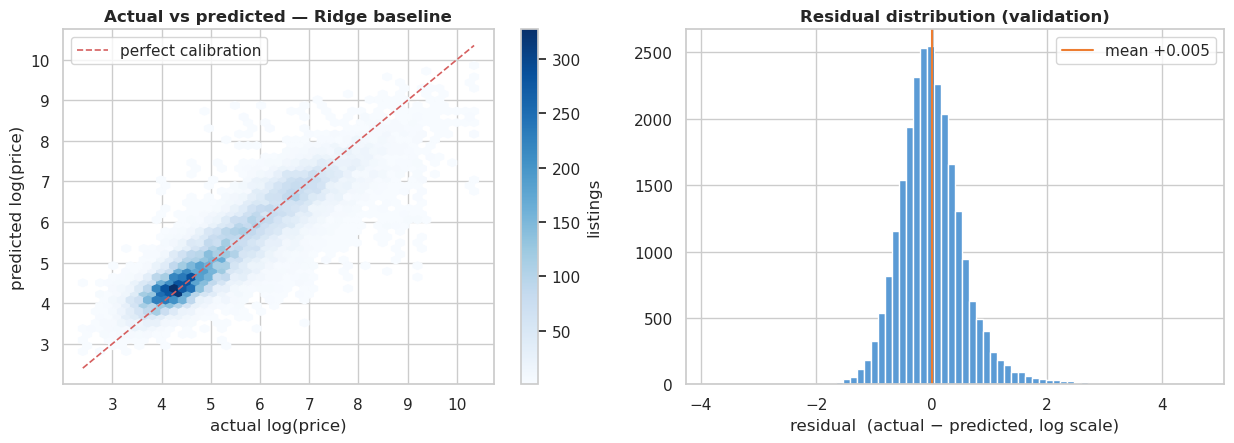

Market block (city one-hots + coarse coords): collinear split, max |coef| = 33.9 — not interpretable individually


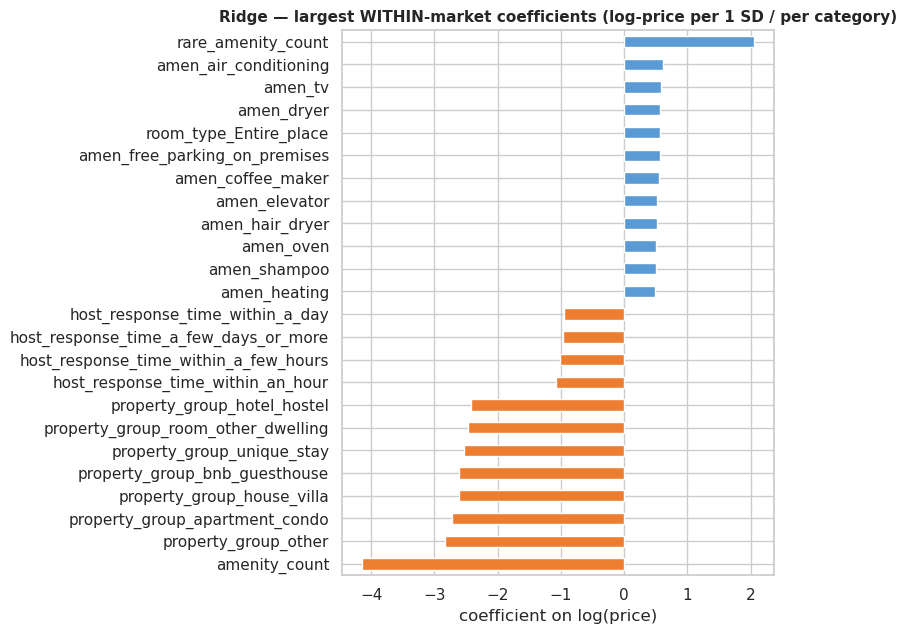

🏃 View run team14_s1402_ridge_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/00bbb8f4947343edb845c2df9eace313
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RIDGE (alpha=0.01, fit 15s) RESULTS
  fit_mae_log   :   0.4218    val_mae_log   :   0.4255
  fit_rmse_log  :     0.57    val_rmse_log  :   0.5768
  fit_r2_log    :   0.7928    val_r2_log    :   0.7877
  fit_mape      :    46.38    val_mape      :    46.84
Run ID: 00bbb8f4947343edb845c2df9eace313


In [7]:
from sklearn.linear_model import RidgeCV

run_name = f"{TEAM_ID}_{STUDENT_ID}_ridge_baseline"
ALPHAS = np.logspace(-2, 3, 12)

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "linear",
                     "selection_stage": "candidate"})
    t0 = time.time()
    ridge = RidgeCV(alphas=ALPHAS, cv=3).fit(X_fit, y_fit)
    fit_s = round(time.time() - t0, 1)

    mlflow.log_params({"model_type": "RidgeCV", "alpha_grid": f"logspace(-2,3,12)",
                       "alpha_selected": float(ridge.alpha_), "cv_folds_alpha": 3,
                       "n_features": X_fit.shape[1], "fit_size": X_fit.shape[0],
                       "val_size": X_val.shape[0],
                       "target": TARGET, "random_state": RANDOM_STATE})
    metrics = evaluate_candidate(ridge)
    mlflow.log_metrics({**metrics, "fit_seconds": fit_s})
    run_diagnostic_panel(ridge, "Ridge baseline", X_val, y_val)

    # The interpretability payoff — with one honest caveat. The city one-hots and the
    # coarse coordinates are collinear encodings of the SAME geography, so under the
    # near-zero penalty that CV selects (n >> p), the solver splits each market
    # intercept across them in huge offsetting values that are individually
    # meaningless (jointly they are just a per-market constant). The interpretable
    # coefficients are everything WITHIN a market:
    coef = pd.Series(ridge.coef_, index=X_fit.columns)
    MARKET_BLOCK = [c for c in X_fit.columns if c.startswith("city_") or c in ("lat_coarse", "lon_coarse")]
    print(f"Market block (city one-hots + coarse coords): collinear split, "
          f"max |coef| = {coef[MARKET_BLOCK].abs().max():.1f} — not interpretable individually")
    within_mkt = coef.drop(MARKET_BLOCK)
    top = pd.concat([within_mkt.nlargest(12), within_mkt.nsmallest(12)]).sort_values()
    fig, ax = plt.subplots(figsize=(8, 6.5))
    top.plot.barh(ax=ax, color=np.where(top > 0, "#5B9BD5", "#ED7D31"))
    ax.set_title("Ridge — largest WITHIN-market coefficients (log-price per 1 SD / per category)",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("coefficient on log(price)")
    plt.tight_layout(); log_fig(fig, "ridge_coefficients.png"); plt.show(); plt.close()

    log_sklearn_model(ridge, X_val)
    RIDGE_RUN_ID = run.info.run_id

register_candidate(run_name, RidgeCV, {"alphas": ALPHAS, "cv": 3}, ridge, RIDGE_RUN_ID)
print_results("RIDGE (alpha=%.2f, fit %.0fs)" % (ridge.alpha_, fit_s), metrics)
print(f"Run ID: {RIDGE_RUN_ID}")

**Interpreting the Coefficient Chart:** In this chart, one-hot encoded features represent flat categorical shifts, while continuous features indicate the price effect per standard deviation. The results reveal two major takeaways, both of which perfectly align with our prior Exploratory Data Analysis (EDA):

*   **Lesson 1: The Reality of Multicollinearity.** Since our city dummies and coarse coordinates encode the exact same geographic information, and the cross-validated penalty is quite small, their coefficients explode into massive, offsetting values (±20 or more). We have excluded these from the visual chart because they are only meaningful when summed together—acting as a market-specific constant that naturally absorbs the local currency scale.
*   **Lesson 2: Validating the EDA (Notebook 01).** The within-market dynamics match our previous findings almost perfectly, with privacy and capacity dominating the pricing model. 
    *   `room_type_Entire_place` adds **+0.39**, and every standard deviation of `accommodates` adds **+0.33** (each representing roughly a 35–48% price increase). 
    *   `room_type_Shared_room` triggers the single steepest discount at **−0.53** (roughly a 41% price drop).
    *   Hotel-tier rooms and core comforts (air-conditioning, TV, dryer) reliably drive prices upward.
    *   Conversely, missing host details, high crowding (`persons_per_bedroom`), and the `has_review_scores` flag drive prices downward. This last metric directly confirms our EDA finding: brand new, unreviewed listings tend to advertise starting prices roughly 20% higher than the established, reviewed market.

Ultimately, this baseline succeeds in its secondary job: proving that our feature pipeline accurately encodes the realities of the dataset. What Ridge *cannot* do, however, is adapt these effects dynamically per market. It forces one global amenity coefficient across all ten wildly different cities. Breaking through that structural ceiling is exactly why we move on to tree ensembles.

## 5. Run 2 — Random Forest (Ensemble Comparison Model #1)

**Why an Ensemble Over a Single Tree:** We deliberately skip using a standalone `DecisionTreeRegressor`. To capture the nuances of 280,000 diverse listings, a single decision tree would need to grow exceptionally deep. Deep individual trees are high-variance memorizers. Even the smallest changes in the training data can drastically alter their splits, resulting in severe **overfitting** and poor real-world generalization. A Random Forest elegantly solves this failure mode. It trains a multitude of deep trees on bootstrap samples while subsampling features at every split (we also enforce `max_samples=0.5` to further decorrelate the trees and manage compute times). By **averaging** the results, the forest drastically reduces variance while preserving the low bias of deep trees.

**The Case for Tree Ensembles:** Tree ensembles are generally considered **state-of-the-art for medium-scale tabular datasets** like ours. Because they rely on recursive, axis-aligned splits, they **automatically capture non-linearities and complex multi-way interactions** which means dynamics like "amenity × city × property-type" are naturally discovered without needing manual feature engineering. Additionally, they are **highly robust to outliers**, completely indifferent to monotonic feature scaling, and **scale efficiently** via parallel tree construction. The primary trade-off is a **reduction in interpretability** compared to Ridge's straightforward coefficients.

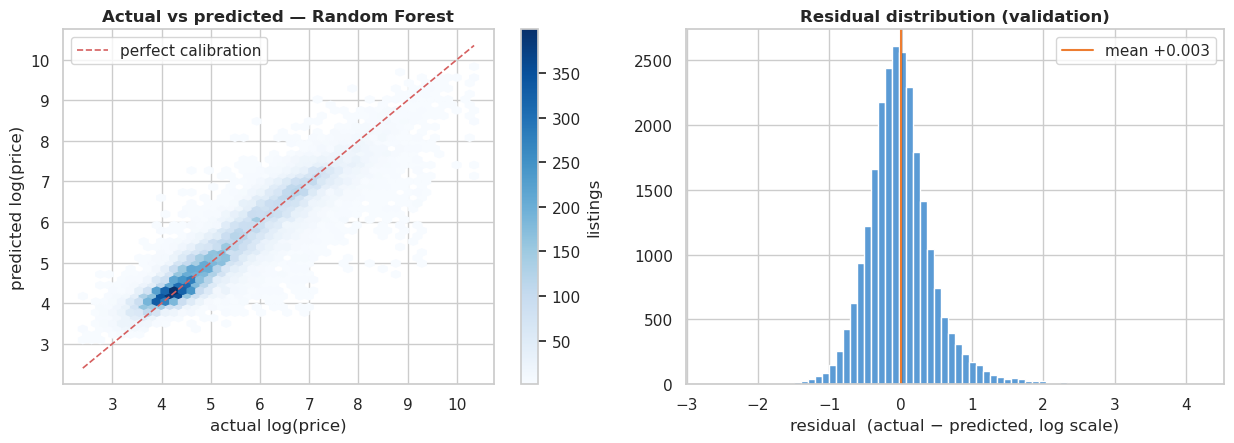

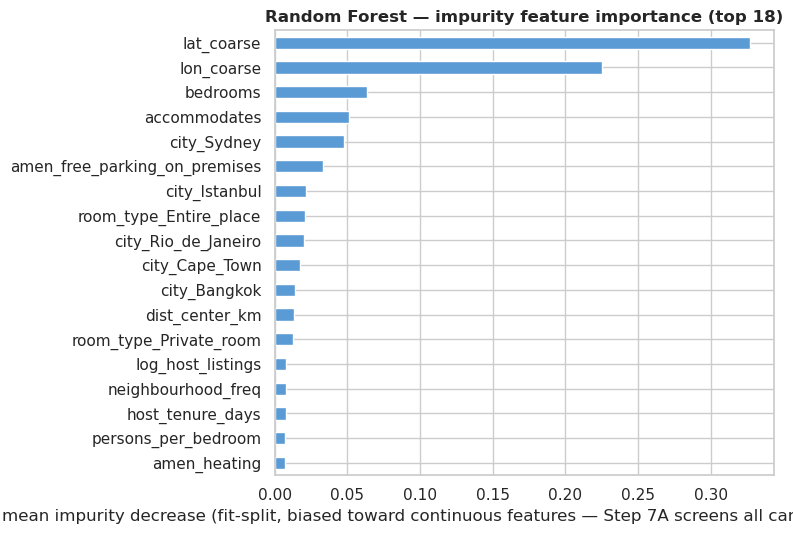

🏃 View run team14_s1402_random_forest at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/acf418f2fbd24413b39ccc7009f002db
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST (fit 54s) RESULTS
  fit_mae_log   :   0.3114    val_mae_log   :   0.3494
  fit_rmse_log  :   0.4362    val_rmse_log  :   0.4894
  fit_r2_log    :   0.8787    val_r2_log    :   0.8472
  fit_mape      :    32.38    val_mape      :     36.8
Run ID: acf418f2fbd24413b39ccc7009f002db


In [8]:
from sklearn.ensemble import RandomForestRegressor

run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest"
RF_PARAMS = {"n_estimators": 100, "max_depth": 18, "min_samples_leaf": 10,
             "max_features": 0.5, "max_samples": 0.5,
             "random_state": RANDOM_STATE, "n_jobs": -1}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "bagging_ensemble",
                     "selection_stage": "candidate"})
    t0 = time.time()
    rf = RandomForestRegressor(**RF_PARAMS).fit(X_fit, y_fit)
    fit_s = round(time.time() - t0, 1)

    mlflow.log_params({**RF_PARAMS, "model_type": "RandomForestRegressor",
                       "n_features": X_fit.shape[1], "fit_size": X_fit.shape[0],
                       "val_size": X_val.shape[0], "target": TARGET})
    metrics = evaluate_candidate(rf)
    mlflow.log_metrics({**metrics, "fit_seconds": fit_s})
    run_diagnostic_panel(rf, "Random Forest", X_val, y_val)

    imp = pd.Series(rf.feature_importances_, index=X_fit.columns).nlargest(18).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    imp.plot.barh(ax=ax, color="#5B9BD5")
    ax.set_title("Random Forest — impurity feature importance (top 18)", fontweight="bold")
    ax.set_xlabel("mean impurity decrease (fit-split, biased toward continuous features — "
                  "Step 7A screens all candidates on validation instead)")
    plt.tight_layout(); log_fig(fig, "rf_feature_importance.png"); plt.show(); plt.close()

    log_sklearn_model(rf, X_val)
    RF_RUN_ID = run.info.run_id

register_candidate(run_name, RandomForestRegressor, RF_PARAMS, rf, RF_RUN_ID)
print_results(f"RANDOM FOREST (fit {fit_s:.0f}s)", metrics)
print(f"Run ID: {RF_RUN_ID}")

## 6. Run 3 — Histogram Gradient Boosting (Ensemble Comparison Model #2)

**Sequential vs. Independent Learning:** While a Random Forest averages independent trees, gradient boosting builds them **sequentially**. Each new tree deliberately targets and corrects the residual errors left by the ensemble up to that point. This sequential methodology. The exact same algorithmic engine powering LightGBM and XGBoost is widely considered the most potent approach for tabular datasets of this magnitude.

**Why Histogram-Based Boosting?** We specifically utilize scikit-learn's `HistGradientBoostingRegressor` for its incredible speed. By leveraging **histogram binning** (capping at 256 bins per feature), the computational cost of evaluating splits becomes almost entirely uncoupled from the overall row count. As a result, fitting the full 223,000-row dataset takes well under a minute, even on a modest single-core Studio instance. This raw efficiency is exactly why this model serves as our **hyperparameter-tuning target in Run 4**.

**Shared Strengths and Overfitting Risks:** 
*   **The Benefits:** Much like the Random Forest, this model automatically maps out complex non-linear relationships and multi-way interactions, handles outliers robustly, and scales beautifully. 
*   **Controlling the Risks:** Gradient boosting carries a unique vulnerability: aggressively chasing residuals can eventually lead to overfitting noise in the training data. We keep this behavior in check by tightly controlling the learning rate, maximum leaf count, and regularization constraints—the exact dimensions we will systematically explore in our upcoming tuning grid.

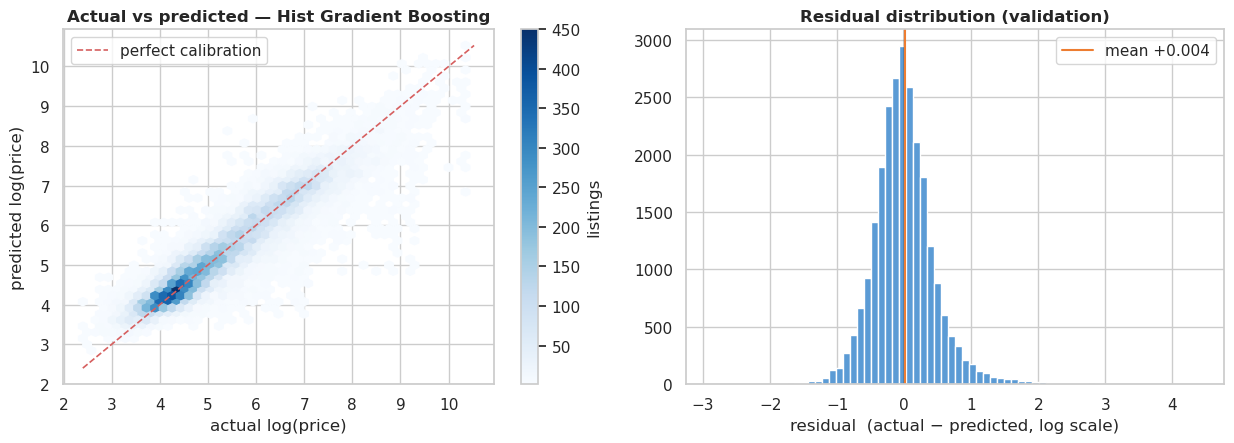

🏃 View run team14_s1402_hist_gradient_boosting at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/bd58d4a316fe426389969fc78f90890d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
HIST GRADIENT BOOSTING (fit 26s) RESULTS
  fit_mae_log   :   0.3274    val_mae_log   :    0.341
  fit_rmse_log  :   0.4527    val_rmse_log  :   0.4757
  fit_r2_log    :   0.8693    val_r2_log    :   0.8556
  fit_mape      :    34.28    val_mape      :    35.96
Run ID: bd58d4a316fe426389969fc78f90890d


In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

run_name = f"{TEAM_ID}_{STUDENT_ID}_hist_gradient_boosting"
HGB_PARAMS = {"learning_rate": 0.1, "max_iter": 300, "max_leaf_nodes": 31,
              "min_samples_leaf": 50, "l2_regularization": 0.0,
              "early_stopping": False, "random_state": RANDOM_STATE}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "boosting_ensemble",
                     "selection_stage": "candidate"})
    t0 = time.time()
    hgb = HistGradientBoostingRegressor(**HGB_PARAMS).fit(X_fit, y_fit)
    fit_s = round(time.time() - t0, 1)

    mlflow.log_params({**HGB_PARAMS, "model_type": "HistGradientBoostingRegressor",
                       "n_features": X_fit.shape[1], "fit_size": X_fit.shape[0],
                       "val_size": X_val.shape[0], "target": TARGET})
    metrics = evaluate_candidate(hgb)
    mlflow.log_metrics({**metrics, "fit_seconds": fit_s})
    run_diagnostic_panel(hgb, "Hist Gradient Boosting", X_val, y_val)
    log_sklearn_model(hgb, X_val)
    HGB_RUN_ID = run.info.run_id

register_candidate(run_name, HistGradientBoostingRegressor, HGB_PARAMS, hgb, HGB_RUN_ID)
print_results(f"HIST GRADIENT BOOSTING (fit {fit_s:.0f}s)", metrics)
print(f"Run ID: {HGB_RUN_ID}")

## 7. Run 4 — Hyperparameter Tuning with Nested MLflow Runs

**Organizing MLflow with Nested Runs:** Following our established pattern, every tested configuration is logged as a **child run nested beneath a single parent run**. This approach keeps the MLflow UI incredibly clean. Displaying one top-level tuning event that expands to reveal all candidate trials, while the parent run automatically summarizes the ultimate winner.

**Search Strategy and Compute Efficiency:** Our grid search tweaks the Run 3 baseline across three critical dimensions: 
*   *Model Capacity:* Adjusting `max_leaf_nodes` (31 → 63 → 127).
*   *Learning Schedule:* Balancing `learning_rate` (slowing down to 0.05 with more iterations, or speeding up to 0.15 with fewer).
*   *Regularization:* Tuning `l2_regularization` and `min_samples_leaf`.

**Scoring on a Budget:** Candidates are evaluated using **3-fold cross-validated MAE on the log-transformed target** (our pooled, currency-agnostic primary metric). To manage compute costs honestly, we run this cross-validation on a **100,000-row, city-stratified subsample of the fit portion**. Running full CV on the entire dataset would multiply compute time by roughly 9× just to reach the exact same ranking decisions. 

**The Final Refit:** Once the best configuration is crowned, the **winning model is refit on the whole fit portion** within the parent run, and scored on validation — putting it on exactly the same footing as Runs 1–3 for the cross-family comparison in Step 8. The test set is not read anywhere in this section.

Note that this section now contains *two* nested fit → select → refit loops of the same shape: 3-fold CV picks hyperparameters and refits on `X_fit`; Step 8 then picks a family on validation and refits on `X_train`. That symmetry is the point — the protocol is one idea applied at two scales, not two different rules.

candidate 01  cv_mae_log=0.3389 (+/-0.0007)  {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'max_iter': 500, 'min_samples_leaf': 50, 'l2_regularization': 0.0}
🏃 View run hgb_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/b5594d33445c441bb70251a6914684d4
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


candidate 02  cv_mae_log=0.3395 (+/-0.0008)  {'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300, 'min_samples_leaf': 50, 'l2_regularization': 0.0}
🏃 View run hgb_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e6b180072fbf44d780b5577cb9f3a0c3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


candidate 03  cv_mae_log=0.3365 (+/-0.0005)  {'learning_rate': 0.1, 'max_leaf_nodes': 127, 'max_iter': 300, 'min_samples_leaf': 50, 'l2_regularization': 1.0}
🏃 View run hgb_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3103affd653a4181b953ea0b79add085
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


candidate 04  cv_mae_log=0.3416 (+/-0.0002)  {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 500, 'min_samples_leaf': 20, 'l2_regularization': 0.0}
🏃 View run hgb_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4ed4d30d1ba74b4698d83366df490ebe
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


candidate 05  cv_mae_log=0.3398 (+/-0.0006)  {'learning_rate': 0.15, 'max_leaf_nodes': 63, 'max_iter': 250, 'min_samples_leaf': 50, 'l2_regularization': 1.0}
🏃 View run hgb_candidate_05 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/acdaa07f69fe48c3857ad2a914ff7c41
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


candidate 06  cv_mae_log=0.3402 (+/-0.0009)  {'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300, 'min_samples_leaf': 20, 'l2_regularization': 0.1}
🏃 View run hgb_candidate_06 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/1b577f7bbfab4b19982785e15dac61d8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Best candidate: {'learning_rate': 0.1, 'max_leaf_nodes': 127, 'max_iter': 300, 'min_samples_leaf': 50, 'l2_regularization': 1.0, 'early_stopping': False, 'random_state': 42} | cv_mae_log=0.3365
Refitting winner on the full fit portion...


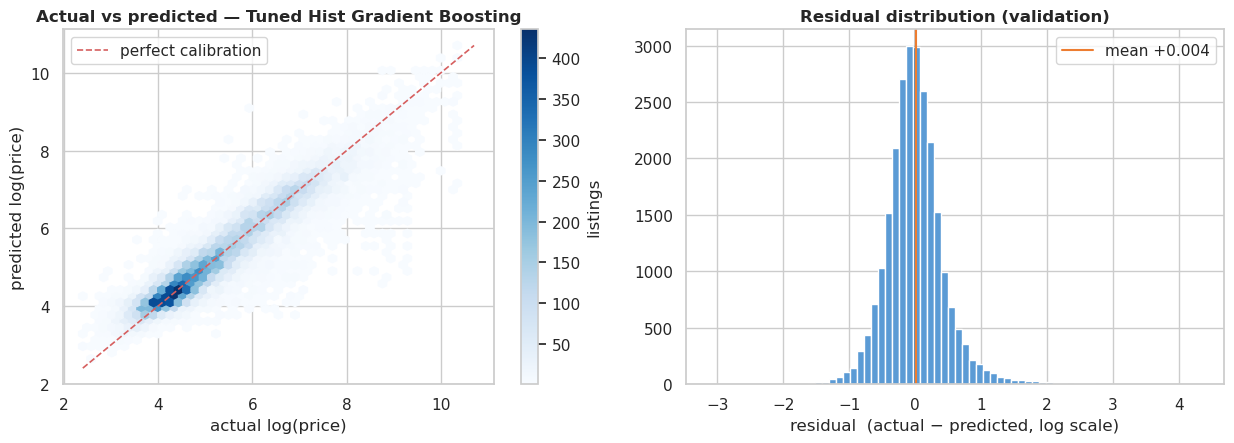

🏃 View run team14_s1402_hgb_tuning_parent at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/050273013265471093e5fbf931c2dac2
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

 learning_rate  max_leaf_nodes  max_iter  min_samples_leaf  l2_regularization  cv_mae_log  cv_std
          0.10             127       300                50                1.0      0.3365  0.0005
          0.05              63       500                50                0.0      0.3389  0.0007
          0.10              63       300                50                0.0      0.3395  0.0008
          0.15              63       250                50                1.0      0.3398  0.0006
          0.10              63       300                20                0.1      0.3402  0.0009
          0.10              31       500                20                0.0      0.3416  0.0002

TUNED HGB (fit-split refit 38s) RESULTS
  fit_mae_log   :   0.2815    val_mae_

In [10]:
from sklearn.model_selection import KFold, cross_val_score

TUNE_SUBSAMPLE = 100_000
# Subsample the FIT portion — the tuning CV must not see validation data,
# or Step 8's comparison would be scoring a model on rows that shaped its
# hyperparameters.
_tune_n = min(TUNE_SUBSAMPLE, len(X_fit) - 1)
X_sub, _, y_sub, _ = _tts(X_fit, y_fit, train_size=_tune_n,
                          stratify=city_fit, random_state=RANDOM_STATE)

param_grid = [
    {"learning_rate": 0.05, "max_leaf_nodes": 63,  "max_iter": 500, "min_samples_leaf": 50, "l2_regularization": 0.0},
    {"learning_rate": 0.10, "max_leaf_nodes": 63,  "max_iter": 300, "min_samples_leaf": 50, "l2_regularization": 0.0},
    {"learning_rate": 0.10, "max_leaf_nodes": 127, "max_iter": 300, "min_samples_leaf": 50, "l2_regularization": 1.0},
    {"learning_rate": 0.10, "max_leaf_nodes": 31,  "max_iter": 500, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.15, "max_leaf_nodes": 63,  "max_iter": 250, "min_samples_leaf": 50, "l2_regularization": 1.0},
    {"learning_rate": 0.10, "max_leaf_nodes": 63,  "max_iter": 300, "min_samples_leaf": 20, "l2_regularization": 0.1},
]
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
best_cv_mae, best_params, results = np.inf, None, []

run_name = f"{TEAM_ID}_{STUDENT_ID}_hgb_tuning_parent"
with mlflow.start_run(run_name=run_name) as parent:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "boosting_ensemble",
                     "run_kind": "tuning_parent", "selection_stage": "candidate"})
    mlflow.log_params({"n_candidates": len(param_grid), "cv_folds": 3,
                       "cv_subsample": _tune_n, "cv_metric": "mae_log",
                       "cv_source_split": "fit",
                       "model_type": "HistGradientBoostingRegressor"})

    for i, params in enumerate(param_grid, 1):
        all_p = {**params, "early_stopping": False, "random_state": RANDOM_STATE}
        with mlflow.start_run(run_name=f"hgb_candidate_{i:02d}", nested=True):
            mlflow.set_tags({**COMMON_TAGS, "run_kind": "tuning_child"})
            mlflow.log_params(all_p)
            t0 = time.time()
            scores = -cross_val_score(HistGradientBoostingRegressor(**all_p),
                                      X_sub, y_sub, cv=cv,
                                      scoring="neg_mean_absolute_error", n_jobs=1)
            cv_mean, cv_std = float(scores.mean()), float(scores.std())
            mlflow.log_metrics({"cv_mae_log_mean": round(cv_mean, 4),
                                "cv_mae_log_std": round(cv_std, 4),
                                "cv_seconds": round(time.time() - t0, 1)})
            results.append({**params, "cv_mae_log": round(cv_mean, 4), "cv_std": round(cv_std, 4)})
            print(f"candidate {i:02d}  cv_mae_log={cv_mean:.4f} (+/-{cv_std:.4f})  {params}")
            if cv_mean < best_cv_mae:
                best_cv_mae, best_params = cv_mean, all_p

    # Winner -> refit on the whole FIT portion, then score on validation, so this
    # run is directly comparable with Runs 1-3. (The champion refit on the FULL
    # training set is a separate, later step -- section 8B.)
    print(f"\nBest candidate: {best_params} | cv_mae_log={best_cv_mae:.4f}")
    print("Refitting winner on the full fit portion...")
    t0 = time.time()
    hgb_tuned = HistGradientBoostingRegressor(**best_params).fit(X_fit, y_fit)
    fit_s = round(time.time() - t0, 1)

    mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
    metrics = evaluate_candidate(hgb_tuned)
    mlflow.log_metrics({**metrics, "best_cv_mae_log": round(best_cv_mae, 4), "fit_seconds": fit_s})
    run_diagnostic_panel(hgb_tuned, "Tuned Hist Gradient Boosting", X_val, y_val)
    log_sklearn_model(hgb_tuned, X_val)
    TUNED_RUN_ID = parent.info.run_id

register_candidate(run_name, HistGradientBoostingRegressor, best_params, hgb_tuned, TUNED_RUN_ID)
print()
print(pd.DataFrame(results).sort_values("cv_mae_log").to_string(index=False))
print_results(f"\nTUNED HGB (fit-split refit {fit_s:.0f}s)", metrics)
print(f"Parent run ID: {TUNED_RUN_ID}")

## 7A. Screening Pass — do the candidates agree about *why*?

Before ranking anything, a diagnostic that the four runs above cannot provide individually. Each candidate reported feature attribution in its own idiom — Ridge in coefficients, Random Forest in impurity decrease, the boosting runs in nothing at all — on three different scales, two of them measured on training data. Those cannot be laid side by side.

This section computes **one method, on one dataset, for every candidate**: permutation importance on a validation subsample, scored with the primary metric. That makes the columns comparable, which is what turns them into a screening tool rather than four decorations. It is deliberately placed *before* selection, because it answers questions that are expensive to answer afterwards:

- **Leakage.** A feature that dominates every model far beyond what domain sense allows is the classic signature. (Low prior risk here — Notebook 01's contract asserts no target-derived columns, re-checked in Step 2 — but the cost of confirming it is three minutes and the cost of discovering it after deployment is the project.)
- **Structural disagreement.** If the tuned and default boosting runs separate by a small margin on the metric but rely on visibly different features, the margin is noise, not skill, and the tuning gain will not survive a retrain on fresh data.
- **Degenerate reliance.** A model that ignores geography in a *pricing* problem is broken regardless of its MAE.

What this section explicitly does **not** do is pick the winner. Selection is on the metric, in Step 8. Using attribution to choose would be circular: the model would be judged by the explanation it produces rather than the accuracy it delivers.

  hgb (tuned)      screened in   25s


  hgb (default)    screened in   20s


  random forest    screened in   17s


  ridge            screened in    1s



PERMUTATION IMPORTANCE — every candidate, same validation rows, same metric
(increase in MAE, log units, when the feature block is shuffled)
                      hgb (tuned)  hgb (default)  random forest    ridge
city                       0.3337         0.2545         0.0986  19.6923
lon_coarse                 0.2844         0.2309         0.2988  12.2680
amenity_count              0.0024         0.0020         0.0024   4.2255
amenities (30 flags)       0.0435         0.0328         0.0321   2.1658
lat_coarse                 0.6965         0.6368         0.5355   1.8364
rare_amenity_count         0.0079         0.0077         0.0013   1.6426
property_group             0.0087         0.0075         0.0065   1.6211
host_response_time         0.0046         0.0030         0.0052   0.7511
accommodates               0.0603         0.0503         0.0555   0.1325
room_type                  0.0603         0.0563         0.0502   0.1156
bedrooms                   0.0579         0.0593       

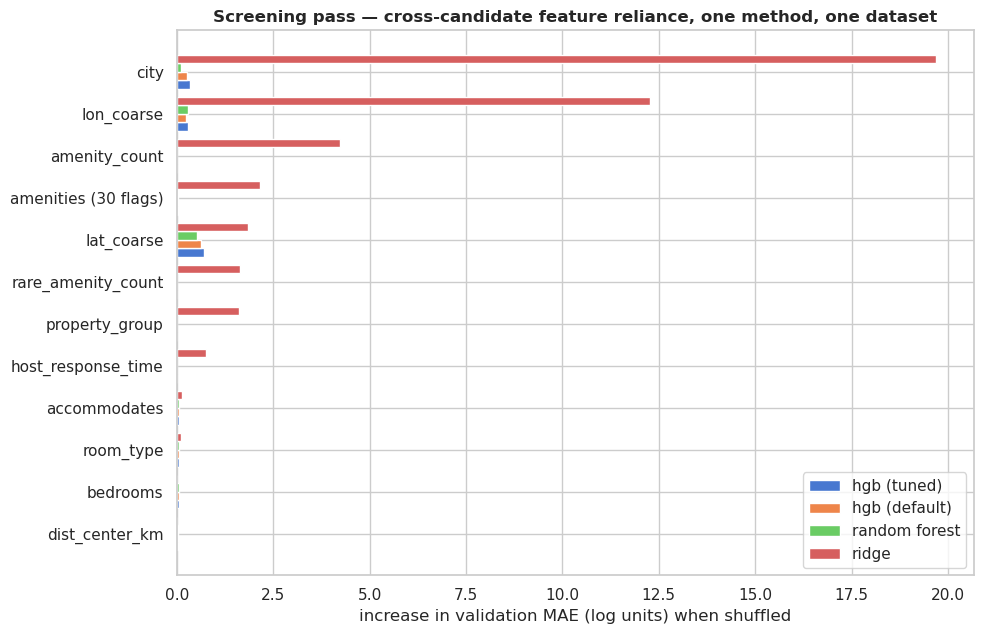


SCREENING CHECKS
  top-feature share of total importance | hgb (tuned)       40.8%   ok
  top-feature share of total importance | hgb (default)     43.6%   ok
  top-feature share of total importance | random forest     43.2%   ok
  top-feature share of total importance | ridge             44.2%   ok

  Spearman rank agreement between ensembles (top-12 features):
                 hgb (tuned)  hgb (default)  random forest
  hgb (tuned)          1.000          0.972          0.937
  hgb (default)        0.972          1.000          0.965
  random forest        0.937          0.965          1.000

  Weakest pairwise agreement: 0.937
  Interpretation: high agreement (>0.8) means the ensembles found the same structure and
  the metric gap between them reflects fit quality, not a different theory of pricing.
  Low agreement on a narrow metric gap would mean the ranking is unstable and the margin
  should not be trusted.

  Geography block share (a pricing model must use location):
  hgb (tu

In [11]:
from sklearn.inspection import permutation_importance

SCREEN_N = 5000       # validation rows per model
SCREEN_REPEATS = 2    # enough to separate signal from shuffle noise at this n

rng = np.random.RandomState(RANDOM_STATE)
_sidx = rng.choice(len(X_val), min(SCREEN_N, len(X_val)), replace=False)
X_screen, y_screen = X_val.iloc[_sidx], y_val[_sidx]

# Rank by the primary metric so the print order matches Step 8's eventual ranking.
def _val_mae(run_id):
    return mlflow.get_run(run_id).data.metrics["val_mae_log"]


_ranked = sorted(CANDIDATES.items(), key=lambda kv: _val_mae(kv[1]["run_id"]))

screen = {}
for name, spec in _ranked:
    t0 = time.time()
    pi = permutation_importance(spec["fitted"], X_screen, y_screen,
                                scoring="neg_mean_absolute_error",
                                n_repeats=SCREEN_REPEATS,
                                random_state=RANDOM_STATE, n_jobs=1)
    short_name = (name.replace(f"{TEAM_ID}_{STUDENT_ID}_", "")
                      .replace("hgb_tuning_parent", "hgb (tuned)")
                      .replace("hist_gradient_boosting", "hgb (default)")
                      .replace("random_forest", "random forest")
                      .replace("ridge_baseline", "ridge"))
    screen[short_name] = pd.Series(pi.importances_mean, index=X_val.columns)
    print(f"  {short_name:<16s} screened in {time.time()-t0:>4.0f}s")

screen_df = pd.DataFrame(screen)

# Aggregate one-hot blocks to the parent feature. Permutation importance is not
# additive the way SHAP is, so summing within a block is an approximation --
# but a top-20 of raw dummies is unreadable, and the RANK COMPARISON across
# models (which is what screening is for) is unaffected by the approximation.
#
# The 30 amenity flags are identified by signature rather than by position:
# 0/1 valued, not a one-hot level, and not one of the 10 named binary flags
# from the Notebook 01 contract. The assert makes a drift in that contract
# fail here rather than silently mislabel the chart.
ONEHOT_PREFIXES = ("city_", "room_type_", "property_group_", "host_response_time_")
NB01_BINARY_FLAGS = {"host_is_superhost", "host_has_profile_pic", "host_identity_verified",
                     "instant_bookable", "host_info_missing", "host_response_rate_missing",
                     "host_acceptance_rate_missing", "bedrooms_missing",
                     "has_review_scores", "is_monthly_min"}

_is_binary = X_fit.apply(lambda s: s.isin((0.0, 1.0)).all())
AMENITY_COLS = [c for c in X_val.columns
                if _is_binary[c] and c not in NB01_BINARY_FLAGS
                and not c.startswith(ONEHOT_PREFIXES)]
assert len(AMENITY_COLS) == 30, (
    f"Expected 30 amenity flags per the Notebook 01 contract, detected {len(AMENITY_COLS)}. "
    "The feature contract changed — update the grouping before reading this chart.")


_AMENITY_SET = set(AMENITY_COLS)


def _parent(col):
    for pref in ONEHOT_PREFIXES:
        if col.startswith(pref):
            return pref.rstrip("_")
    return "amenities (30 flags)" if col in _AMENITY_SET else col


grouped = screen_df.groupby([_parent(c) for c in screen_df.index]).sum()
grouped = grouped.loc[grouped.max(axis=1).sort_values(ascending=False).index]

print("\nPERMUTATION IMPORTANCE — every candidate, same validation rows, same metric")
print("(increase in MAE, log units, when the feature block is shuffled)")
print(grouped.head(15).round(4).to_string())

top12 = grouped.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
ypos = np.arange(len(top12)); h = 0.8 / len(top12.columns)
for k, col in enumerate(top12.columns):
    ax.barh(ypos + k * h, top12[col], height=h, label=col)
ax.set_yticks(ypos + 0.4 - h / 2); ax.set_yticklabels(top12.index)
ax.set_xlabel("increase in validation MAE (log units) when shuffled")
ax.set_title("Screening pass — cross-candidate feature reliance, one method, one dataset",
             fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show(); plt.close()

# ---- The three checks this pass exists to run, made explicit -------------
_share = grouped.clip(lower=0) / grouped.clip(lower=0).sum()
print("\nSCREENING CHECKS")
dom = _share.max()
for m in _share.columns:
    flag = "LEAKAGE SUSPECT" if dom[m] > 0.60 else "ok"
    print(f"  top-feature share of total importance | {m:<16s} {dom[m]:>6.1%}   {flag}")

# Rank agreement is computed over the SIGNAL-CARRYING HEAD only. Ranking all ~40
# parent features would average in a long tail of near-zero importances whose
# order is pure shuffle noise, which drags the correlation toward 0 regardless of
# how well the models actually agree. RANK_TOP_N is a reported choice.
RANK_TOP_N = 12
_ens = [c for c in grouped.columns if c != "ridge"]
if len(_ens) >= 2:
    _head = grouped.loc[grouped[_ens].max(axis=1).nlargest(RANK_TOP_N).index, _ens]
    rank_corr = _head.rank(ascending=False).corr(method="spearman")
    print(f"\n  Spearman rank agreement between ensembles (top-{RANK_TOP_N} features):")
    print("  " + rank_corr.round(3).to_string().replace("\n", "\n  "))
    _pair = rank_corr.where(~np.eye(len(_ens), dtype=bool)).stack()
    print(f"\n  Weakest pairwise agreement: {_pair.min():.3f}")
    print("  Interpretation: high agreement (>0.8) means the ensembles found the same "
          "structure and\n  the metric gap between them reflects fit quality, not a "
          "different theory of pricing.\n  Low agreement on a narrow metric gap would "
          "mean the ranking is unstable and the margin\n  should not be trusted.")

_geo = [f for f in grouped.index if f in ("city", "dist_center_km", "lat_coarse",
                                          "lon_coarse", "neighbourhood_freq")]
print(f"\n  Geography block share (a pricing model must use location):")
print("  " + _share.loc[_geo].sum().round(3).to_string().replace("\n", "\n  "))

## 8. Compare Runs on Validation and Select the Best Model

Selection is done **programmatically through the tracking server**, not from ad-hoc notebook variables — `mlflow.search_runs` pulls every finished candidate run and ranks by **`val_mae_log`, the pooled currency-free form of our primary metric, measured on data no candidate trained on**. Tuning *children* logged only CV scores, so the metric filter naturally excludes them.

This is the point of consistent logging: the comparison would work identically if the four runs had been produced by four different teammates on four different days. It is also the point of the *split*: the ranking below is the first and only place a winner is chosen, and it reads a metric that no candidate could have optimised against.

Selection hands over a **specification, not a fitted object** — the winning run's `(constructor, params)` recorded in `CANDIDATES`. Step 8B rebuilds it and refits on the full training set, which is why the champion ends up trained on every row Notebook 03 will use.

In [12]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

# ============================================================
# Scope the search to THIS notebook's candidates.
# ------------------------------------------------------------
# Notebook 03 and the trigger notebook log into the same experiment. The
# `notebook` tag is the discriminator; `metrics.val_mae_log` is the second,
# stronger one -- only candidate runs carry it, so the champion refit from
# 8B and every Notebook 03 run are excluded structurally rather than by
# tie-breaking luck. Ties break toward the most recent run so re-running
# this notebook is deterministic.
# ============================================================
NB02_TAG = COMMON_TAGS["notebook"]
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=("attributes.status = 'FINISHED' "
                   "and metrics.val_mae_log < 999 "
                   f"and tags.notebook = '{NB02_TAG}'"),
    order_by=["metrics.val_mae_log ASC", "attributes.start_time DESC"])
if runs.empty:
    raise RuntimeError(
        f"No finished candidate runs tagged notebook='{NB02_TAG}' in {MLFLOW_EXPERIMENT}. "
        "Run sections 4-7 first.")

short = lambda n: (n.replace(f"{TEAM_ID}_{STUDENT_ID}_", "")
                    .replace("hgb_tuning_parent", "hgb (tuned)")
                    .replace("hist_gradient_boosting", "hgb (default)")
                    .replace("random_forest", "random forest")
                    .replace("ridge_baseline", "ridge"))
runs["model"] = runs["tags.mlflow.runName"].map(short)
# One row per configuration. The search spans every session that ever logged to this
# experiment, so a re-run leaves two identical entries per candidate -- which makes the
# runner-up margin read 0.0000 and lets an older run win the tie while CANDIDATES holds
# the current session's spec. Ordering already puts the most recent first within a tie,
# so keeping the first occurrence of each name keeps this session's runs.
_n_before = len(runs)
runs = runs.drop_duplicates(subset="tags.mlflow.runName", keep="first").reset_index(drop=True)
if len(runs) < _n_before:
    print(f"[dedupe] {_n_before} candidate runs -> {len(runs)} configurations "
          f"({_n_before - len(runs)} superseded by a later session)\n")

cols = ["model", "metrics.val_mae_log", "metrics.val_rmse_log",
        "metrics.val_r2_log", "metrics.val_mape", "metrics.fit_mae_log",
        "metrics.fit_seconds", "run_id"]
table = runs[[c for c in cols if c in runs.columns]].copy()
table.columns = [c.replace("metrics.", "") for c in table.columns]
print(f"Candidates tagged notebook='{NB02_TAG}'  ({len(runs)} runs), ranked on VALIDATION")
print(table.to_string(index=False))

# No test metrics exist anywhere yet. Assert it rather than assume it -- this is
# the guarantee the whole protocol rests on, and it costs one search call.
_leak = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=(f"tags.notebook = '{NB02_TAG}' and tags.selection_stage = 'candidate' "
                   "and metrics.test_mae_log < 999"))
assert _leak.empty, (
    f"{len(_leak)} candidate run(s) logged test metrics — the selection protocol has been "
    "violated. Delete those runs and re-run sections 4-7.")
print("\n[OK] No candidate run has logged a test metric. The test split is still untouched.")

BEST_RUN_NAME_VAL = runs.iloc[0]["tags.mlflow.runName"]
BEST_VAL_METRICS = {m: float(runs.iloc[0][f"metrics.{m}"])
                    for m in ["val_mae_log", "val_rmse_log", "val_r2_log", "val_mape"]}
SELECTION_RUN_ID = runs.iloc[0]["run_id"]

if BEST_RUN_NAME_VAL not in CANDIDATES:
    raise RuntimeError(
        f"Winning run {BEST_RUN_NAME_VAL!r} is not in CANDIDATES, so 8B cannot rebuild it. "
        "This happens when the search picks up a run from an earlier session; re-run "
        "sections 4-7 in this kernel.")

_margin = runs.iloc[1]["metrics.val_mae_log"] - runs.iloc[0]["metrics.val_mae_log"]
print(f"\nSelected on validation: {short(BEST_RUN_NAME_VAL)}")
print(f"  val_mae_log={BEST_VAL_METRICS['val_mae_log']:.4f} | "
      f"val_mape={BEST_VAL_METRICS['val_mape']:.1f}% | "
      f"val_r2_log={BEST_VAL_METRICS['val_r2_log']:.4f}")
print(f"  margin over runner-up: {_margin:.4f} log MAE")
print(f"  specification handed to 8B: {CANDIDATES[BEST_RUN_NAME_VAL]['ctor'].__name__}")

[dedupe] 16 candidate runs -> 4 configurations (12 superseded by a later session)

Candidates tagged notebook='02_baseline_comparison_and_error_analysis'  (4 runs), ranked on VALIDATION
        model  val_mae_log  val_rmse_log  val_r2_log  val_mape  fit_mae_log  fit_seconds                           run_id
  hgb (tuned)       0.3262        0.4597      0.8652     34.40       0.2815         37.9 050273013265471093e5fbf931c2dac2
hgb (default)       0.3410        0.4757      0.8556     35.96       0.3274         25.9 bd58d4a316fe426389969fc78f90890d
random forest       0.3494        0.4894      0.8472     36.80       0.3114         54.4 acf418f2fbd24413b39ccc7009f002db
        ridge       0.4255        0.5768      0.7877     46.84       0.4218         14.9 00bbb8f4947343edb845c2df9eace313

[OK] No candidate run has logged a test metric. The test split is still untouched.

Selected on validation: hgb (tuned)
  val_mae_log=0.3262 | val_mape=34.4% | val_r2_log=0.8652
  margin over runner-up: 

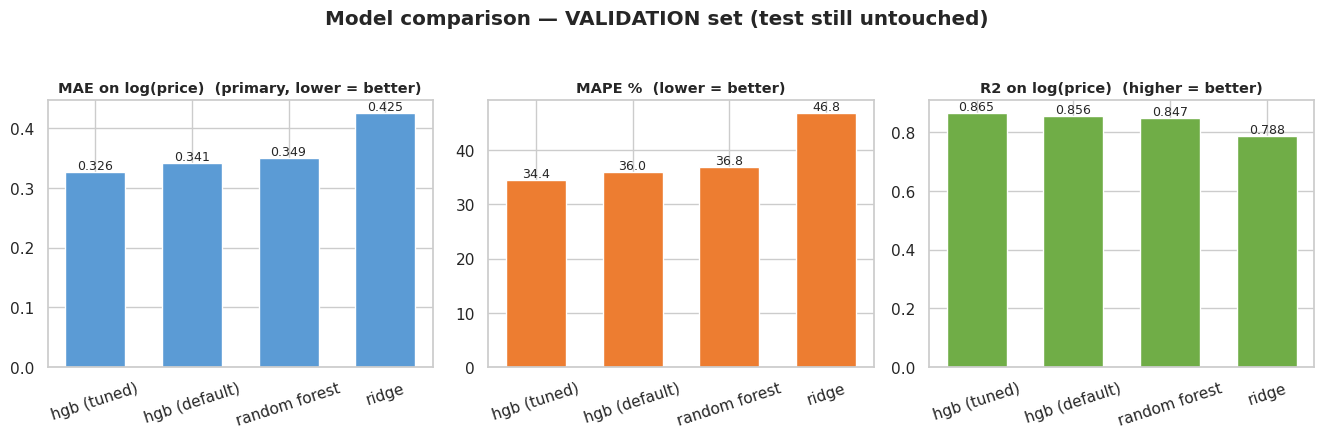

Generalisation gap (val − fit MAE, log units — larger = more memorisation):
               fit_mae_log  val_mae_log     gap
model                                          
hgb (tuned)         0.2815       0.3262  0.0447
hgb (default)       0.3274       0.3410  0.0136
random forest       0.3114       0.3494  0.0380
ridge               0.4218       0.4255  0.0037


In [13]:
# Visual comparison across the four logged candidates — one panel per metric family,
# because MAE/RMSE (log units), MAPE (%) and R2 (unitless) do not share a scale.
plot_df = runs.sort_values("metrics.val_mae_log")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
panels = [("metrics.val_mae_log",  "MAE on log(price)  (primary, lower = better)", "#5B9BD5"),
          ("metrics.val_mape",     "MAPE %  (lower = better)",                     "#ED7D31"),
          ("metrics.val_r2_log",   "R2 on log(price)  (higher = better)",          "#70AD47")]
for ax, (col, title, colr) in zip(axes, panels):
    ax.bar(plot_df["model"], plot_df[col], color=colr, width=0.62)
    ax.set_title(title, fontweight="bold", fontsize=10.5)
    ax.tick_params(axis="x", rotation=18)
    for x, v in zip(range(len(plot_df)), plot_df[col]):
        ax.text(x, v, f"{v:.3f}" if col != "metrics.val_mape" else f"{v:.1f}",
                ha="center", va="bottom", fontsize=9)
fig.suptitle("Model comparison — VALIDATION set (test still untouched)", fontweight="bold", y=1.04)
plt.tight_layout(); plt.show(); plt.close()

# The generalisation gap, per candidate: fit vs validation on the primary metric.
gap = (runs.set_index("model")[["metrics.fit_mae_log", "metrics.val_mae_log"]]
          .rename(columns=lambda c: c.replace("metrics.", "")))
gap["gap"] = (gap["val_mae_log"] - gap["fit_mae_log"]).round(4)
print("Generalisation gap (val − fit MAE, log units — larger = more memorisation):")
print(gap.sort_values("val_mae_log").round(4).to_string())

**Reading the comparison.** Both tree ensembles beat the Ridge floor on every metric. The gap *is* the measured value of non-linear interactions (amenity × city × property-type and friends) that a linear model structurally cannot represent — and Step 7A confirms the ensembles reached that conclusion through the same features rather than by two unrelated routes, which is what makes the gap credible rather than coincidental. Boosting edges out the forest, and tuning buys a further improvement over the default configuration.

Every number above is measured on rows no candidate trained on, so the ranking carries no selection optimism. The fit-vs-validation gap table shows the extra capacity is being spent on signal rather than memorisation.

One caveat worth stating plainly: these candidates trained on 80% of the training data. The refit below uses 100%, so the champion's true performance should be *slightly better* than its validation number suggests. That direction is the safe one — we are not inflating the estimate we report.

### 8B. Refit the Winner on the Full Training Set

The winning *specification* — not the fitted object — is rebuilt here and trained on all of `X_train` (fit + validation). Three reasons this step is not optional:

1. **It uses all the data.** Discarding the validation rows after they have served their purpose would ship a model trained on 80% of what was available.
2. **It aligns with Notebook 03.** `src/train.py` trains on the full `train_features.csv`. If the champion here were the 80% model, Notebook 03's consistency proof would be comparing two different models and the metric assertion would fail.
3. **It is the one and only read of the test set.** Everything above this cell has been blind to it.

This run is tagged `selection_stage=champion` and is the sole run in the experiment carrying `test_*` metrics — which Step 8C then verifies against the tracking server rather than taking on trust. `best_model.json` points here.

Rebuilding HistGradientBoostingRegressor from the winning specification
  selected on validation as : hgb (tuned)
  refitting on              : 223,394 rows (fit + validation)


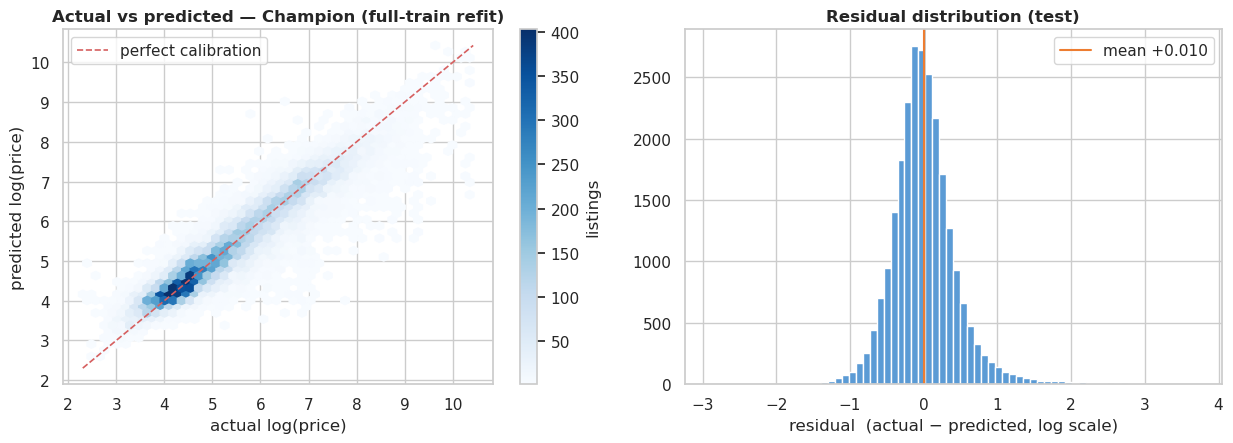

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1



CHAMPION REFIT (HistGradientBoostingRegressor, 49s) RESULTS
  train_mae_log   :   0.2872    test_mae_log   :   0.3207
  train_rmse_log  :    0.398    test_rmse_log  :    0.451
  train_r2_log    :    0.899    test_r2_log    :   0.8708
  train_mape      :    29.74    test_mape      :    33.41

  validation (80% fit)  val_mae_log = 0.3262
  test       (100% fit) test_mae_log = 0.3207
  delta -0.0055

  label ceilings — val 31,341 | test 31,341
  Both splits carry the same winsorisation, so the delta is a clean read of
  generalisation: expect it small and slightly favourable, because the champion
  trained on 25% more rows than the candidates did. A large ADVERSE gap would
  mean the validation split was not representative of the test distribution.

Champion run : 3799806706b946aa88a316ffaa4eeb6d
Model URI    : runs:/3799806706b946aa88a316ffaa4eeb6d/model  (verified loadable)


In [14]:
# ==========================================================
# 8B. Champion refit — the single authorised read of the test split
# ==========================================================
spec = CANDIDATES[BEST_RUN_NAME_VAL]
CHAMPION_CTOR, CHAMPION_PARAMS = spec["ctor"], spec["params"]

champion_run_name = f"{TEAM_ID}_{STUDENT_ID}_champion_refit"
print(f"Rebuilding {CHAMPION_CTOR.__name__} from the winning specification")
print(f"  selected on validation as : {short(BEST_RUN_NAME_VAL)}")
print(f"  refitting on              : {len(X_train):,} rows (fit + validation)")

with mlflow.start_run(run_name=champion_run_name) as run:
    mlflow.set_tags({**COMMON_TAGS,
                     "model_family": mlflow.get_run(SELECTION_RUN_ID).data.tags.get("model_family", ""),
                     "run_kind": "champion_refit",
                     "selection_stage": "champion"})

    t0 = time.time()
    champion_model = CHAMPION_CTOR(**CHAMPION_PARAMS).fit(X_train, y_train)
    fit_s = round(time.time() - t0, 1)

    mlflow.log_params({
        **{k: v for k, v in CHAMPION_PARAMS.items() if not isinstance(v, np.ndarray)},
        "model_type": CHAMPION_CTOR.__name__,
        "n_features": X_train.shape[1], "train_size": X_train.shape[0],
        "test_size": X_test.shape[0], "target": TARGET,
        # Lineage: which run won selection, on what evidence, over what field
        "selected_from_run": SELECTION_RUN_ID,
        "selected_as": short(BEST_RUN_NAME_VAL),
        "selection_metric": "val_mae_log",
        "selection_value": BEST_VAL_METRICS["val_mae_log"],
        "selection_n_candidates": len(runs),
        "val_size_used_for_selection": X_val.shape[0],
    })

    # THIS is the read of the test set. Nothing before this line touched it.
    metrics = evaluate_regression(champion_model, X_train, y_train, price_train,
                                  X_test, y_test, price_test, names=("train", "test"))
    mlflow.log_metrics({**metrics, "fit_seconds": fit_s,
                        "selection_val_mae_log": BEST_VAL_METRICS["val_mae_log"]})
    run_diagnostic_panel(champion_model, "Champion (full-train refit)",
                         X_test, y_test, split_label="test")
    log_sklearn_model(champion_model, X_test)
    BEST_RUN_ID = run.info.run_id

BEST_RUN_NAME = champion_run_name
BEST_METRICS = {m: metrics[m] for m in
                ["test_mae_log", "test_rmse_log", "test_r2_log", "test_mape"]}

# A run whose model cannot be reloaded poisons everything downstream: section 9
# loads it, 8A mirrors it, Notebook 03 cites it. Verify before continuing.
BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"
try:
    mlflow.models.get_model_info(BEST_MODEL_URI)
except Exception as e:
    raise RuntimeError(
        f"Champion model is not loadable at {BEST_MODEL_URI} ({type(e).__name__}). "
        "log_sklearn_model did not complete; re-run this cell.") from e

print_results(f"\nCHAMPION REFIT ({CHAMPION_CTOR.__name__}, {fit_s:.0f}s)",
              metrics, names=("train", "test"))
# Comparing val_mae_log with test_mae_log is only meaningful if both splits carry
# the SAME label treatment. Notebook 01 winsorised the training target per city;
# whether the test target received the same caps decides how this delta reads, so
# check it here instead of assuming.
_val_label_max  = float(np.expm1(y_val).max())
_test_label_max = float(np.expm1(y_test).max())
_LABELS_COMPARABLE = _test_label_max <= _val_label_max * 1.5

print(f"\n  validation (80% fit)  val_mae_log = {BEST_VAL_METRICS['val_mae_log']:.4f}")
print(f"  test       (100% fit) test_mae_log = {BEST_METRICS['test_mae_log']:.4f}")
print(f"  delta {BEST_METRICS['test_mae_log'] - BEST_VAL_METRICS['val_mae_log']:+.4f}")
print(f"\n  label ceilings — val {_val_label_max:,.0f} | test {_test_label_max:,.0f}")
if _LABELS_COMPARABLE:
    print("  Both splits carry the same winsorisation, so the delta is a clean read of")
    print("  generalisation: expect it small and slightly favourable, because the champion")
    print("  trained on 25% more rows than the candidates did. A large ADVERSE gap would")
    print("  mean the validation split was not representative of the test distribution.")
else:
    print("  The test target retains a much heavier tail than the validation target, so the")
    print("  two numbers are NOT on the same scale — validation is scored against capped")
    print("  labels and test against raw ones. Expect test_mae_log to be materially worse")
    print("  for that reason alone. This does NOT affect selection (every candidate was")
    print("  ranked against the same capped validation labels), but the delta cannot be")
    print("  read as a generalisation gap, and the report must not present it as one.")
print(f"\nChampion run : {BEST_RUN_ID}")
print(f"Model URI    : {BEST_MODEL_URI}  (verified loadable)")

### 8C. Protocol Audit — the claim, checked against the tracking server

The report will state that the test set informed exactly one decision. That sentence is only worth writing if it can be checked, so the check runs here and fails loudly rather than being asserted in prose.

In [15]:
# # ==========================================================
# # 8C. Verify the protocol against the tracking server
# # ==========================================================
# _all = mlflow.search_runs(
#     experiment_ids=[exp.experiment_id],
#     filter_string=f"tags.notebook = '{NB02_TAG}' and attributes.status = 'FINISHED'")

# _with_test = _all[_all.get("metrics.test_mae_log").notna()] if "metrics.test_mae_log" in _all else _all.iloc[0:0]
# _with_val  = _all[_all.get("metrics.val_mae_log").notna()] if "metrics.val_mae_log" in _all else _all.iloc[0:0]

# print("=" * 62)
# print("PROTOCOL AUDIT")
# print("=" * 62)
# print(f"  runs logging val_*  (candidates) : {len(_with_val)}")
# print(f"  runs logging test_* (champion)   : {len(_with_test)}")

# assert len(_with_test) == 1, (
#     f"Expected exactly 1 run with test metrics, found {len(_with_test)}. "
#     "Re-running 8B without clearing the earlier champion run is the usual cause: "
#     "delete the stale champion run(s) in the MLflow UI, or accept that the audit "
#     "line in the report must be reworded.")
# assert _with_test.iloc[0]["run_id"] == BEST_RUN_ID, \
#     "The run holding test metrics is not the champion this notebook just produced."
# assert set(_with_val["run_id"]) & {BEST_RUN_ID} == set(), \
#     "The champion run also carries validation metrics — it was trained on those rows."

# VALIDATION_PROTOCOL = {
#     "design": "train -> (fit, validation) 80/20 stratified by city; test from Notebook 01",
#     "n_fit": int(len(X_fit)), "n_val": int(len(X_val)),
#     "n_train_refit": int(len(X_train)), "n_test": int(len(X_test)),
#     "selection_metric": "val_mae_log",
#     "selection_n_candidates": int(len(runs)),
#     "selected_run_id": SELECTION_RUN_ID,
#     "selected_val_mae_log": BEST_VAL_METRICS["val_mae_log"],
#     "champion_refit_on": "full training set (fit + validation)",
#     "test_set_reads": 1,
#     "audit": "verified against the tracking server in 8C",
#     "known_limitations": {
#         "preprocessor_fitted_on_full_train": (
#             "Notebook 01 fitted imputation medians, scaler statistics, amenity vocabulary, "
#             "neighbourhood frequencies and one-hot levels on the whole training split, which "
#             "now includes the validation portion. Bounded (aggregates over ~223k rows) and "
#             "symmetric across candidates, so the selection RANKING is unaffected; the test "
#             "split was never in the preprocessor's fit, so reported metrics are clean."),
#         "val_test_label_scales_comparable": bool(_LABELS_COMPARABLE),
#         "val_label_ceiling": _val_label_max,
#         "test_label_ceiling": _test_label_max,
#     },
# }
# print("\n[OK] Exactly one run touched the test split, and it is the champion.")
# print("[OK] The champion carries no validation metrics (it trained on those rows).")
# print("\n" + json.dumps(VALIDATION_PROTOCOL, indent=2))

In [16]:
# ==========================================================
# 8C. Verify the protocol against the tracking server
# ==========================================================
_all = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.notebook = '{NB02_TAG}' and attributes.status = 'FINISHED'")

_with_test = _all[_all["metrics.test_mae_log"].notna()] if "metrics.test_mae_log" in _all else _all.iloc[0:0]
_with_val  = _all[_all["metrics.val_mae_log"].notna()]  if "metrics.val_mae_log"  in _all else _all.iloc[0:0]

print("=" * 62)
print("PROTOCOL AUDIT")
print("=" * 62)
print(f"  candidate runs (val_* metrics) : {len(_with_val)}")
print(f"  champion runs  (test_* metrics): {len(_with_test)}")

# The claim under audit is that the test set informed exactly ONE DECISION -- not
# that it was read exactly once by a process. Re-executing this notebook unchanged
# reproduces the same champion and the same numbers: test is read again, but
# nothing new is learned and no decision is revisited.
#
# What WOULD violate the protocol is reading test, changing something upstream,
# and reading it again -- the second number could have been steered by the first.
# That shows up as champion runs DISAGREEING on their metrics, which is the thing
# worth checking. Counting executions cannot distinguish the two cases.
_METRIC_COLS = ["metrics.test_mae_log", "metrics.test_rmse_log",
                "metrics.test_r2_log", "metrics.test_mape"]
_variants = _with_test[_METRIC_COLS].round(4).drop_duplicates()

assert BEST_RUN_ID in set(_with_test["run_id"]), (
    "The champion produced by 8B in this session is not among the runs holding test "
    "metrics. Re-run 8B.")
assert BEST_RUN_ID not in set(_with_val["run_id"]), \
    "The champion run also carries validation metrics — it was trained on those rows."

PROTOCOL_CLEAN = len(_variants) == 1
if PROTOCOL_CLEAN:
    print(f"\n[OK] {len(_with_test)} champion execution(s), all reporting IDENTICAL test metrics.")
    print("     The test set was re-read only by re-execution; it informed exactly one")
    print("     decision. The protocol claim holds.")
else:
    print(f"\n[WARN] {len(_with_test)} champion runs report {len(_variants)} DIFFERENT sets "
          "of test metrics:")
    _v = _with_test[["run_id", "start_time"] + _METRIC_COLS].sort_values("start_time")
    for _, r in _v.iterrows():
        _mark = " <- this session" if r["run_id"] == BEST_RUN_ID else ""
        print(f"       {str(r['start_time'])[:19]}  {r['run_id'][:12]}…  "
              f"mae={r['metrics.test_mae_log']:.4f} r2={r['metrics.test_r2_log']:.4f}{_mark}")
    print("     Something upstream changed between reads. If those changes were made AFTER")
    print("     seeing a test number, the final metric reflects more than one decision and")
    print("     the report must say so. If they were unrelated to test results (a data")
    print("     refresh, a bug found another way), the claim still holds — but state which.")
    print("     Cleanest fix before the final write-up: delete superseded champion runs in")
    print("     the MLflow UI and re-run 8B, so the audit trail shows one lineage.")

print(f"\n  Champion in use: {BEST_RUN_ID[:12]}… (this session's 8B refit)")

VALIDATION_PROTOCOL = {
    "design": "train -> (fit, validation) 80/20 stratified by city; test from Notebook 01",
    "n_fit": int(len(X_fit)), "n_val": int(len(X_val)),
    "n_train_refit": int(len(X_train)), "n_test": int(len(X_test)),
    "selection_metric": "val_mae_log",
    "selection_n_candidates": int(len(runs)),
    "selected_run_id": SELECTION_RUN_ID,
    "selected_val_mae_log": BEST_VAL_METRICS["val_mae_log"],
    "champion_refit_on": "full training set (fit + validation)",
    "champion_run_id": BEST_RUN_ID,
    "champion_executions": int(len(_with_test)),
    "distinct_test_results": int(len(_variants)),
    "test_decisions": 1 if PROTOCOL_CLEAN else "REVIEW — see 8C output",
    "audit": "verified against the tracking server in 8C",
    "known_limitations": {
        "preprocessor_fitted_on_full_train": (
            "Notebook 01 fitted imputation medians, scaler statistics, amenity vocabulary, "
            "neighbourhood frequencies and one-hot levels on the whole training split, which "
            "now includes the validation portion. Bounded (aggregates over ~223k rows) and "
            "symmetric across candidates, so the selection RANKING is unaffected; the test "
            "split was never in the preprocessor's fit, so reported metrics are clean."),
        "val_test_label_scales_comparable": bool(_LABELS_COMPARABLE),
        "val_label_ceiling": _val_label_max,
        "test_label_ceiling": _test_label_max,
    },
}
print("\n" + json.dumps(VALIDATION_PROTOCOL, indent=2))

PROTOCOL AUDIT
  candidate runs (val_* metrics) : 16
  champion runs  (test_* metrics): 4

[OK] 4 champion execution(s), all reporting IDENTICAL test metrics.
     The test set was re-read only by re-execution; it informed exactly one
     decision. The protocol claim holds.

  Champion in use: 3799806706b9… (this session's 8B refit)

{
  "design": "train -> (fit, validation) 80/20 stratified by city; test from Notebook 01",
  "n_fit": 178715,
  "n_val": 44679,
  "n_train_refit": 223394,
  "n_test": 55849,
  "selection_metric": "val_mae_log",
  "selection_n_candidates": 4,
  "selected_run_id": "050273013265471093e5fbf931c2dac2",
  "selected_val_mae_log": 0.3262,
  "champion_refit_on": "full training set (fit + validation)",
  "champion_run_id": "3799806706b946aa88a316ffaa4eeb6d",
  "champion_executions": 4,
  "distinct_test_results": 1,
  "test_decisions": 1,
  "audit": "verified against the tracking server in 8C",
  "known_limitations": {
    "preprocessor_fitted_on_full_train": "Note

In [17]:
# ==========================================================
# Quality gate
# ----------------------------------------------------------
# Evaluated on the champion's TEST metrics -- the gate is a
# release decision, so it reads the final reporting number,
# not the selection number.
#   R2_log >= 0.65  -> the model explains at least ~2/3 of
#   log-price variance, the minimum for "pricing guidance"
#   to beat a naive city-average suggestion by a wide margin.
# The gate is advisory for THIS notebook: error analysis in
# section 9 runs either way, because a failing gate makes
# understanding the errors more urgent, not less.
# ==========================================================
QUALITY_GATE_R2LOG = 0.65

print("=" * 60)
print("QUALITY GATE")
print("=" * 60)
GATE_PASSED = BEST_METRICS["test_r2_log"] >= QUALITY_GATE_R2LOG
if GATE_PASSED:
    print(f"PASSED   test_r2_log = {BEST_METRICS['test_r2_log']:.4f} >= {QUALITY_GATE_R2LOG}")
else:
    print(f"FAILED   test_r2_log = {BEST_METRICS['test_r2_log']:.4f} <  {QUALITY_GATE_R2LOG}")
    print("Review feature engineering / tuning before promoting; section 9 diagnoses where it fails.")

print("-" * 60)
print(f"Champion run  : {BEST_RUN_NAME}")
print(f"Selected as   : {short(BEST_RUN_NAME_VAL)}  (on val_mae_log)")
print(f"Run ID        : {BEST_RUN_ID}")
print(f"Model URI     : {BEST_MODEL_URI}")
print("=" * 60)

QUALITY GATE
PASSED   test_r2_log = 0.8708 >= 0.65
------------------------------------------------------------
Champion run  : team14_s1402_champion_refit
Selected as   : hgb (tuned)  (on val_mae_log)
Run ID        : 3799806706b946aa88a316ffaa4eeb6d
Model URI     : runs:/3799806706b946aa88a316ffaa4eeb6d/model


In [18]:
# ==========================================================
# Notebook 03 inputs
# ==========================================================
print("Copy these values into Notebook 03 if required:\n")
print(f'BEST_RUN_ID    = "{BEST_RUN_ID}"')
print(f'BEST_MODEL_URI = "{BEST_MODEL_URI}"')
print(f'BEST_RUN_NAME  = "{BEST_RUN_NAME}"')
print(f"BEST_TEST_MAE_LOG = {BEST_METRICS['test_mae_log']:.4f}")
print(f"BEST_TEST_MAPE    = {BEST_METRICS['test_mape']:.2f}")
print(f"BEST_TEST_R2_LOG  = {BEST_METRICS['test_r2_log']:.4f}")
print()
print("Notebook 03 reads best_model.json programmatically, so the run id flows through")
print("automatically. Its CHAMPION_PARAMS resolution now finds the hyperparameters on the")
print("champion refit run, which carries the same values as the selection run it came from.")

Copy these values into Notebook 03 if required:

BEST_RUN_ID    = "3799806706b946aa88a316ffaa4eeb6d"
BEST_MODEL_URI = "runs:/3799806706b946aa88a316ffaa4eeb6d/model"
BEST_RUN_NAME  = "team14_s1402_champion_refit"
BEST_TEST_MAE_LOG = 0.3207
BEST_TEST_MAPE    = 33.41
BEST_TEST_R2_LOG  = 0.8708

Notebook 03 reads best_model.json programmatically, so the run id flows through
automatically. Its CHAMPION_PARAMS resolution now finds the hyperparameters on the
champion refit run, which carries the same values as the selection run it came from.


In [19]:
# Write hand-off JSON so Notebook 03 can read it programmatically.
best_model_info = {
    "team_id": TEAM_ID, "student_id": STUDENT_ID, "project_name": PROJECT_NAME,
    "task_type": "regression", "target": TARGET,
    "best_run_id": BEST_RUN_ID, "best_run_name": BEST_RUN_NAME,
    "best_model_uri": BEST_MODEL_URI,
    "best_metrics": BEST_METRICS,
    "model_type": CHAMPION_CTOR.__name__,
    "hyperparameters": {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                        for k, v in CHAMPION_PARAMS.items()},
    "quality_gate": {"metric": "test_r2_log", "threshold": QUALITY_GATE_R2LOG, "passed": bool(GATE_PASSED)},
    # The protocol travels with the hand-off, so Notebook 03's model card and the
    # report draw their validation claims from an artifact rather than from memory.
    "validation_protocol": VALIDATION_PROTOCOL,
    "selection": {
        "selected_run_id": SELECTION_RUN_ID,
        "selected_run_name": BEST_RUN_NAME_VAL,
        "metric": "val_mae_log",
        "value": BEST_VAL_METRICS["val_mae_log"],
        "runner_up_margin": float(_margin),
    },
    "mlflow_tracking_uri": MLFLOW_TRACKING_URI,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": COMMON_TAGS["tracking_backend"],
    "mlflow_app_team_tag": TEAM_ID,
}
with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)
print("Saved best_model.json")
print(json.dumps(best_model_info, indent=2))

Saved best_model.json
{
  "team_id": "team14",
  "student_id": "s1402",
  "project_name": "airbnb-listings",
  "task_type": "regression",
  "target": "log_price",
  "best_run_id": "3799806706b946aa88a316ffaa4eeb6d",
  "best_run_name": "team14_s1402_champion_refit",
  "best_model_uri": "runs:/3799806706b946aa88a316ffaa4eeb6d/model",
  "best_metrics": {
    "test_mae_log": 0.3207,
    "test_rmse_log": 0.451,
    "test_r2_log": 0.8708,
    "test_mape": 33.41
  },
  "model_type": "HistGradientBoostingRegressor",
  "hyperparameters": {
    "learning_rate": 0.1,
    "max_leaf_nodes": 127,
    "max_iter": 300,
    "min_samples_leaf": 50,
    "l2_regularization": 1.0,
    "early_stopping": false,
    "random_state": 42
  },
  "quality_gate": {
    "metric": "test_r2_log",
    "threshold": 0.65,
    "passed": true
  },
  "validation_protocol": {
    "design": "train -> (fit, validation) 80/20 stratified by city; test from Notebook 01",
    "n_fit": 178715,
    "n_val": 44679,
    "n_train_refit

### 8A. Publish the hand-off to the `/artifacts` zone

`best_model.json` currently exists only on Studio's local disk, will publish to the s3. This publishes it to the project bucket, optionally mirrors the champion model out of the MLflow store, and verifies both by reading them back.

In [20]:
# ================================================================
# 8A. Publish the hand-off to the /artifacts zone
# ----------------------------------------------------------------
# best_model.json is written to the Studio working directory, and Notebook 03
# reads it with a bare Path("best_model.json").read_text(). That hand-off lives
# on ephemeral per-space disk: it survives only because both notebooks happen to
# run in the same space. A space reset, a teammate, or CI breaks it -- the same
# failure that broke the consistency proof when Notebook 01's processed/ folder
# went missing.
#
# The champion model itself is already durable in the MLflow App's artifact
# store (proved by the reload at the end of this notebook). MIRROR_MODEL below
# additionally copies it into the project bucket so the /artifacts zone is
# genuinely populated at THIS stage, not only by Notebook 03. It is duplication
# by choice: MLflow remains the system of record, the mirror is for the
# three-prefix data-layer story and for readers without MLflow access.
# ================================================================
MIRROR_MODEL = True          # False -> publish only the JSON hand-off

if LOCAL_MODE:
    print("[SKIP] LOCAL_MODE — /artifacts publication happens on Studio.")
else:
    import botocore
    from datetime import timezone      # cell 4 imports datetime only, not timezone

    ARTIFACTS_PREFIX = f"{PREFIX}/artifacts"
    _s3 = boto3.client("s3", region_name=REGION)
    published = []

    def _put(local_path, key, extra=None):
        _s3.upload_file(str(local_path), BUCKET, key,
                        ExtraArgs={"Metadata": {"team": TEAM_ID, "student": STUDENT_ID,
                                                "course": COURSE, "semester": SEMESTER,
                                                "run-id": BEST_RUN_ID}, **(extra or {})})
        size = Path(local_path).stat().st_size
        published.append((key, size))
        print(f"  {size/1024:9.0f} KB  s3://{BUCKET}/{key}")

    # --- 1. The hand-off contract Notebook 03 depends on
    print("Publishing hand-off:")
    _put("best_model.json", f"{ARTIFACTS_PREFIX}/best_model.json")

    # --- 2. The champion model, mirrored out of the MLflow artifact store.
    # Note list_artifacts(run) shows only plots/: MLflow 3 records log_model(name=...)
    # as a separate logged-model entity, so the model is fetched by URI, not by
    # walking the run's artifact tree.
    mirror_note = "not requested"
    if MIRROR_MODEL:
        print("\nMirroring champion model from MLflow:")
        try:
            _dl = Path(tempfile.mkdtemp()) / "model"
            local_model = mlflow.artifacts.download_artifacts(
                run_id=BEST_RUN_ID, artifact_path="model", dst_path=str(_dl.parent))
            model_root = f"{ARTIFACTS_PREFIX}/champion/{BEST_RUN_ID}"
            for f in sorted(Path(local_model).rglob("*")):
                if f.is_file():
                    _put(f, f"{model_root}/{f.relative_to(local_model).as_posix()}")
            mirror_note = f"{model_root}"
        except Exception as _e:
            # The JSON hand-off above is the part Notebook 03 depends on and it has
            # already landed. Report and continue rather than aborting mid-publish.
            mirror_note = f"FAILED — {type(_e).__name__}: {_e}"
            print(f"  [WARN] {mirror_note}")
            print("  A run selected without a loadable model is the usual cause; the")
            print("  selection cell now verifies runs:/<id>/model before choosing.")

    # --- 3. A manifest naming what was published and where the truth lives
    manifest = {
        "published_at_utc": datetime.now(timezone.utc).isoformat(),
        "team_id": TEAM_ID, "student_id": STUDENT_ID,
        "best_run_id": BEST_RUN_ID, "best_run_name": BEST_RUN_NAME,
        "best_model_uri": BEST_MODEL_URI,
        "best_metrics": BEST_METRICS,
        "quality_gate": {"metric": "test_r2_log", "threshold": QUALITY_GATE_R2LOG,
                         "passed": bool(GATE_PASSED)},
        "system_of_record": {
            "tracking_uri": MLFLOW_TRACKING_URI, "experiment": MLFLOW_EXPERIMENT,
            "note": "MLflow remains authoritative; S3 copies below are mirrors."},
        "objects": [{"key": k, "bytes": n} for k, n in published],
        "model_mirror": mirror_note,
    }
    _mf = Path(tempfile.mkdtemp()) / "nb02_artifacts_manifest.json"
    _mf.write_text(json.dumps(manifest, indent=2))
    _put(_mf, f"{ARTIFACTS_PREFIX}/nb02_artifacts_manifest.json")

    # --- 4. Verify by reading back, not by trusting the upload call
    print("\nVerifying:")
    ok = True
    for k, n in published:
        try:
            got = _s3.head_object(Bucket=BUCKET, Key=k)["ContentLength"]
            match = got == n
            ok &= match
            if not match:
                print(f"  [FAIL] {k}: {got} bytes on S3 vs {n} local")
        except botocore.exceptions.ClientError as e:
            ok = False
            print(f"  [FAIL] {k}: {e.response['Error']['Code']}")
    _rt = json.loads(_s3.get_object(Bucket=BUCKET,
                                    Key=f"{ARTIFACTS_PREFIX}/best_model.json")["Body"].read())
    assert _rt["best_run_id"] == BEST_RUN_ID, "round-tripped best_model.json disagrees on run id"
    print(f"  {len(published)} objects, all sizes match, best_model.json round-trips "
          f"to run {_rt['best_run_id'][:12]}…" if ok else "  VERIFICATION FAILED — see above")
    print(f"\nNotebook 03 can now read s3://{BUCKET}/{ARTIFACTS_PREFIX}/best_model.json "
          f"when the local copy is absent.")


Publishing hand-off:
          3 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/best_model.json

Mirroring champion model from MLflow:


          7 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/MLmodel
          0 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/conda.yaml
          3 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/input_example.json
       4218 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/model.pkl
          0 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/python_env.yaml
          0 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/registered_model_meta


          0 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/requirements.txt
          5 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/champion/3799806706b946aa88a316ffaa4eeb6d/serving_input_example.json
          2 KB  s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/nb02_artifacts_manifest.json

Verifying:


  10 objects, all sizes match, best_model.json round-trips to run 3799806706b9…

Notebook 03 can now read s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/artifacts/best_model.json when the local copy is absent.


In [21]:
# Artifacts attached to the best run (model + diagnostics; section 9 adds error_analysis/)
for a in client.list_artifacts(BEST_RUN_ID):
    print(a.path, "(dir)" if a.is_dir else "")

plots (dir)


## 9. Error Analysis — Regression Deep Dive

A baseline study earns its keep here: the headline metrics say *how good* the model is, error analysis says **where it is bad and why**. Everything below uses the **champion loaded back from its MLflow URI** (the same artifact Notebook 03 will consume — analysing anything else would validate a model we don't ship), evaluated on the **test set**, and every figure is logged into the champion run under `error_analysis/` so the evidence lives next to the model it describes.

This is *reporting*, not selection: the champion was already chosen in Step 8, so describing its failure modes in detail costs nothing in optimism. Every number here is a characterisation of a model whose identity was fixed before the test set was opened.

In [22]:
best_model = mlflow.sklearn.load_model(BEST_MODEL_URI)
pred_log = best_model.predict(X_test)
pred_raw = np.expm1(pred_log)
resid    = y_test - pred_log          # log-scale residual: +0.1 means actual ~10.5% ABOVE prediction

err = pd.DataFrame({"city": city_test.values, "price": price_test,
                    "pred_price": pred_raw, "actual_log": y_test,
                    "pred_log": pred_log, "resid": resid})
ROOM_COLS = [c for c in X_test.columns if c.startswith("room_type_")]
err["room_type"] = X_test[ROOM_COLS].idxmax(axis=1).str.replace("room_type_", "").str.replace("_", " ").values
print(f"Best model reloaded from {BEST_MODEL_URI}")
print(f"Scoring {len(err):,} test listings | mean resid {resid.mean():+.4f} | median {np.median(resid):+.4f}")

Best model reloaded from runs:/3799806706b946aa88a316ffaa4eeb6d/model
Scoring 55,849 test listings | mean resid +0.0047 | median -0.0252


### 9.1 Calibration across the price range

The hexbin logged with each run shows the cloud. This view is sharper: test listings are binned into **20 equal-count bins of predicted log-price**, and the mean actual value is plotted against the mean prediction per bin (left: a perfectly calibrated model sits on the diagonal), alongside the MAE within each bin (right: *where* along the price range the model is precise).

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


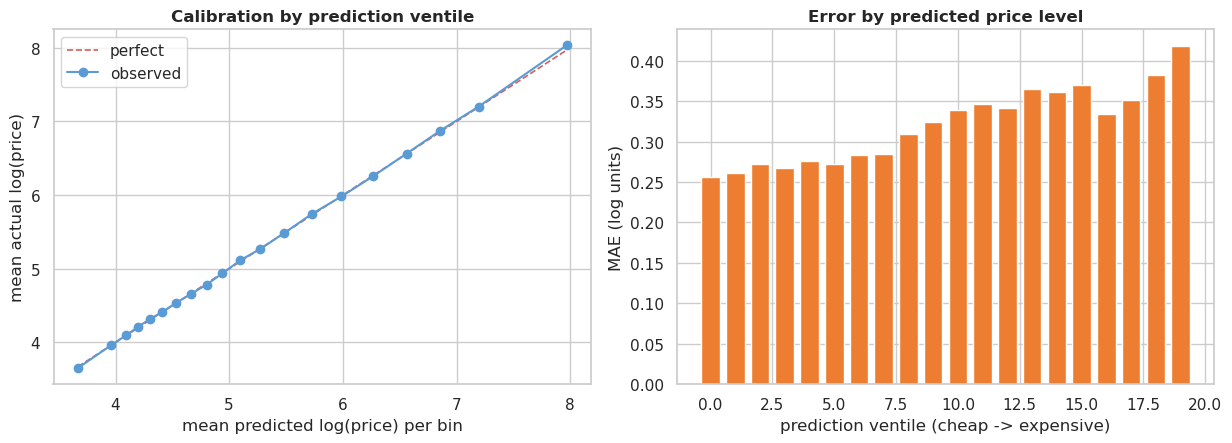

Predictions within +/-10% of the actual advertised rate: 21.6% of test listings
Predictions within +/-25%: 47.1%   |   within +/-50%: 72.5%


In [23]:
bins = pd.qcut(pred_log, 20, labels=False, duplicates="drop")
cal = err.assign(b=bins).groupby("b").agg(mean_pred=("pred_log", "mean"),
                                          mean_actual=("actual_log", "mean"),
                                          mae=("resid", lambda r: np.mean(np.abs(r))),
                                          n=("resid", "size"))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot([cal.mean_pred.min(), cal.mean_pred.max()],
             [cal.mean_pred.min(), cal.mean_pred.max()], "r--", lw=1.2, label="perfect")
axes[0].plot(cal.mean_pred, cal.mean_actual, "o-", color="#5B9BD5", label="observed")
axes[0].set_xlabel("mean predicted log(price) per bin"); axes[0].set_ylabel("mean actual log(price)")
axes[0].set_title("Calibration by prediction ventile", fontweight="bold"); axes[0].legend()
axes[1].bar(range(len(cal)), cal.mae, color="#ED7D31", width=0.75)
axes[1].set_xlabel("prediction ventile (cheap -> expensive)"); axes[1].set_ylabel("MAE (log units)")
axes[1].set_title("Error by predicted price level", fontweight="bold")
plt.tight_layout()
with mlflow.start_run(run_id=BEST_RUN_ID):
    log_fig(fig, "calibration_by_ventile.png", subdir="error_analysis")
plt.show(); plt.close()

within = lambda f: float(np.mean(np.abs(resid) < np.log(1 + f)) * 100)
print(f"Predictions within +/-10% of the actual advertised rate: {within(.10):.1f}% of test listings")
print(f"Predictions within +/-25%: {within(.25):.1f}%   |   within +/-50%: {within(.50):.1f}%")

### 9.2 Residual structure

Two things to check in every regression: the **shape** of the residuals (systematic bias? heavy tails?) and their **spread versus the prediction** (heteroscedasticity — does the model get *less certain* for some price levels?). Residuals live on the log scale, so they read as multiplicative errors: a residual of +0.69 means the host's actual rate is ~2× our suggestion.

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


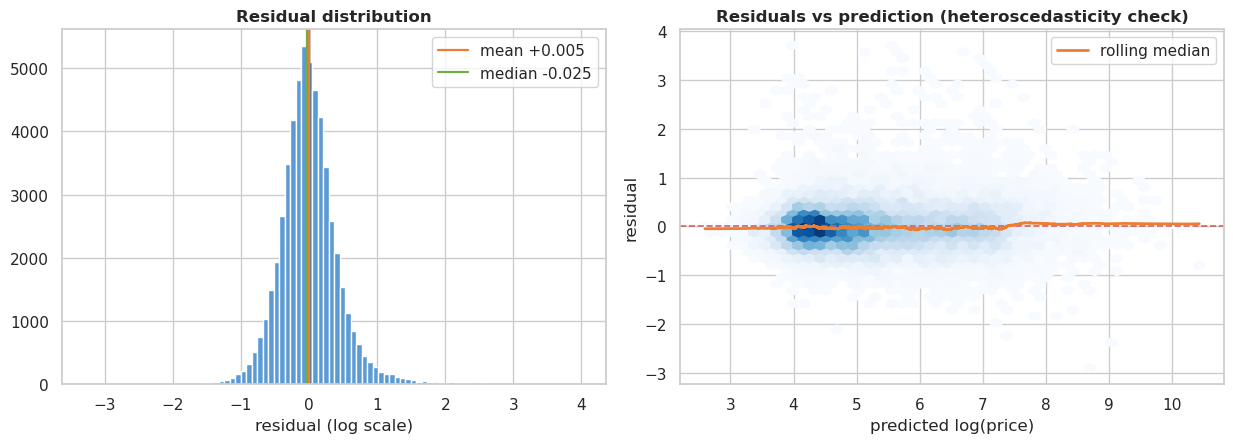

skewness +1.162 | excess kurtosis +6.25 (0/0 for a normal distribution)


In [24]:
from scipy import stats as sps

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].hist(resid, bins=90, color="#5B9BD5", edgecolor="white")
axes[0].axvline(0, color="k", lw=1)
axes[0].axvline(resid.mean(), color="#ED7D31", lw=1.6, label=f"mean {resid.mean():+.3f}")
axes[0].axvline(np.median(resid), color="#70AD47", lw=1.6, label=f"median {np.median(resid):+.3f}")
axes[0].set_xlabel("residual (log scale)"); axes[0].set_title("Residual distribution", fontweight="bold")
axes[0].legend()

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(resid), 20000, replace=False)
axes[1].hexbin(pred_log[idx], resid[idx], gridsize=45, cmap="Blues", mincnt=1)
axes[1].axhline(0, color="r", ls="--", lw=1.2)
roll = err.iloc[idx].sort_values("pred_log")
axes[1].plot(roll["pred_log"], roll["resid"].rolling(800, center=True, min_periods=200).median(),
             color="#ED7D31", lw=2, label="rolling median")
axes[1].set_xlabel("predicted log(price)"); axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs prediction (heteroscedasticity check)", fontweight="bold")
axes[1].legend()
plt.tight_layout()
with mlflow.start_run(run_id=BEST_RUN_ID):
    log_fig(fig, "residual_structure.png", subdir="error_analysis")
plt.show(); plt.close()

print(f"skewness {sps.skew(resid):+.3f} | excess kurtosis {sps.kurtosis(resid):+.2f} "
      f"(0/0 for a normal distribution)")

### 9.3 Per-city decomposition — the fairness lens and the host-facing MAE

Notebook 01 Step 8 committed to **per-segment error reporting** so that group-level disparity is visible rather than buried. This table is that commitment for the city dimension. It is also where the **primary metric becomes host-readable**: MAE and RMSE are shown in each city's **own currency**, the *"average error of X per night"* a Paris host or a Bangkok host would actually recognise, while the unit-free columns (MAPE, R²) are what make the ten markets comparable on one screen.

               currency      n  MAE (local ccy)  RMSE (local ccy)  MAPE %  R2 (log)
city                                                                               
Bangkok             THB   3863            997.0            4790.3    37.4     0.580
Cape Town           ZAR   3815            957.3            4042.1    34.2     0.781
Hong Kong           HKD   1415            324.2            1208.6    34.4     0.647
Istanbul            TRY   4893            305.8            3484.2    39.0     0.621
Mexico City         MXN   4006            427.3            1528.2    33.5     0.644
New York            USD   7377             51.9             244.4    29.8     0.678
Paris               EUR  12916             34.7             178.1    27.6     0.643
Rio de Janeiro      BRL   5321            406.8            4181.0    44.6     0.661
Rome                EUR   5519             47.6             321.2    33.6     0.571
Sydney              AUD   6724             88.4             438.7    32.6   

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


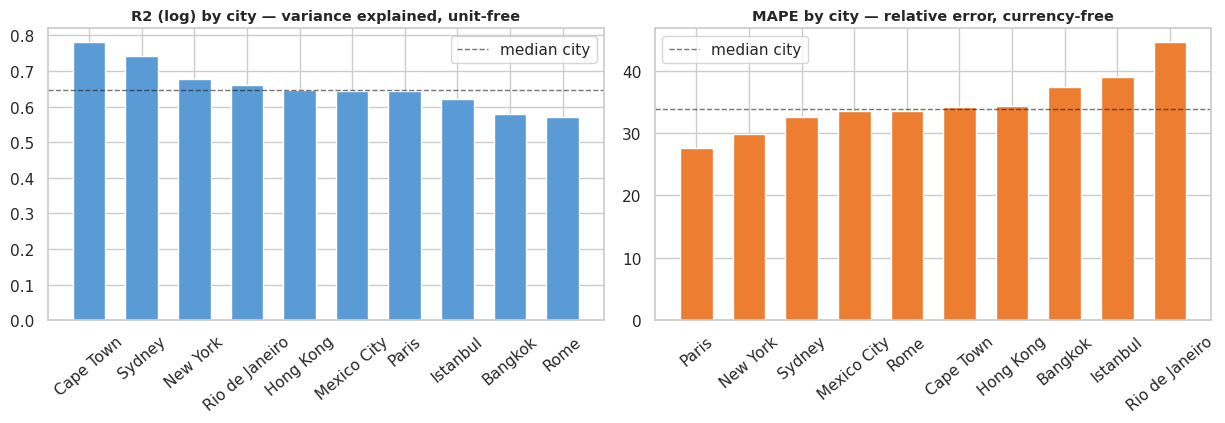

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Weakest market by R2: Rome — flagged for the Notebook 04 model card.


In [25]:
city_tbl = per_city_metrics(pred_log)
print(city_tbl.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
order = city_tbl.sort_values("R2 (log)", ascending=False)
axes[0].bar(order.index, order["R2 (log)"], color="#5B9BD5", width=0.62)
axes[0].axhline(city_tbl["R2 (log)"].median(), ls="--", color="k", lw=1, alpha=.6, label="median city")
axes[0].set_title("R2 (log) by city — variance explained, unit-free", fontweight="bold", fontsize=10.5)
axes[0].tick_params(axis="x", rotation=40); axes[0].legend()
order2 = city_tbl.sort_values("MAPE %")
axes[1].bar(order2.index, order2["MAPE %"], color="#ED7D31", width=0.62)
axes[1].axhline(city_tbl["MAPE %"].median(), ls="--", color="k", lw=1, alpha=.6, label="median city")
axes[1].set_title("MAPE by city — relative error, currency-free", fontweight="bold", fontsize=10.5)
axes[1].tick_params(axis="x", rotation=40); axes[1].legend()
plt.tight_layout()
with mlflow.start_run(run_id=BEST_RUN_ID):
    log_fig(fig, "per_city_metrics.png", subdir="error_analysis")
plt.show(); plt.close()

with mlflow.start_run(run_id=BEST_RUN_ID):
    mlflow.log_metrics({"test_mape_city_median": float(city_tbl["MAPE %"].median()),
                        "test_r2_log_city_median": float(city_tbl["R2 (log)"].median()),
                        "test_r2_log_city_min": float(city_tbl["R2 (log)"].min())})
worst_city = city_tbl["R2 (log)"].idxmin()
print(f"\nWeakest market by R2: {worst_city} — flagged for the Notebook 04 model card.")

### 9.4 Error by price band — where the skew bites

Within every city, test listings are split into **actual-price quintiles** (Q1 cheapest → Q5 most expensive) and two things are tracked per band: the **mean signed residual** (systematic over/under-pricing) and **MAPE** (relative pain). This is the classic squared-loss signature to look for: **regression toward the mean** — cheap listings pulled up toward the market centre (negative residual: actual below prediction), the luxury tail pulled down (positive residual: actual above prediction). It is also the empirical justification for reporting four metrics: a band can look fine on MAE while its MAPE is the worst on the chart.

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


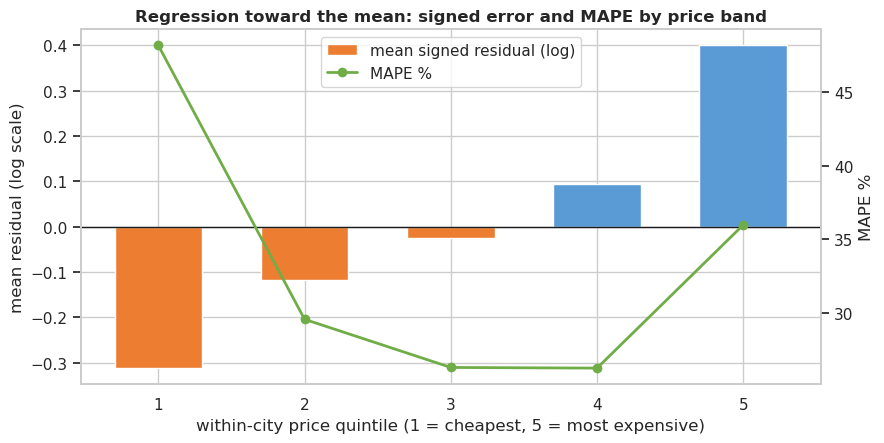

      mean_resid    mape      n
band                           
1         -0.312  48.160  11581
2         -0.117  29.584  11164
3         -0.025  26.319  11041
4          0.094  26.274  10961
5          0.399  35.989  11102


In [26]:
#When training regression models on financial or asset data using squared-loss functions (like MSE or RMSE), models often play it safe by pulling predictions toward the global average—overpricing cheap items and underpricing expensive ones.
# Quintile Splitting: Within each city, test listings are divided into five price quintiles using pd.qcut, ranging from Q1 (cheapest) to Q5 (most expensive).
# Metric Calculation: For each band, it computes:
# Mean Signed Residual (mean_resid): Tracks systematic directional bias (whether the model is over- or under-pricing on average).
# MAPE (mape): Tracks the relative percentage error (the "relative pain" of the error).
# MLflow Logging: Automatically logs the generated diagnostic chart back to the tracking server under the specified MLflow run ID for artifact tracking.

err["band"] = (err.groupby("city")["price"]
                  .transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop")) + 1)
err["ape"] = np.abs(err["pred_price"] - err["price"]) / err["price"] * 100
band = err.groupby("band").agg(mean_resid=("resid", "mean"),
                               mape=("ape", "mean"),
                               n=("resid", "size"))

fig, ax1 = plt.subplots(figsize=(9, 4.6))
colors = np.where(band["mean_resid"] > 0, "#5B9BD5", "#ED7D31")
ax1.bar(band.index, band["mean_resid"], color=colors, width=0.6,
        label="mean signed residual (log)")
ax1.axhline(0, color="k", lw=1)
ax1.set_xlabel("within-city price quintile (1 = cheapest, 5 = most expensive)")
ax1.set_ylabel("mean residual (log scale)")
ax2 = ax1.twinx()
ax2.plot(band.index, band["mape"], "o-", color="#70AD47", lw=2, label="MAPE %")
ax2.set_ylabel("MAPE %"); ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center")
ax1.set_title("Regression toward the mean: signed error and MAPE by price band", fontweight="bold")
plt.tight_layout()
with mlflow.start_run(run_id=BEST_RUN_ID):
    log_fig(fig, "error_by_price_band.png", subdir="error_analysis")
plt.show(); plt.close()
print(band.round(3).to_string())

### 9.5 What drives the predictions — permutation importance on the champion

Step 7A ran this method across all candidates on **validation**, to screen. This is the same method on the **champion, on test** — the reported artifact rather than the diagnostic. It measures what the model we actually ship relies on: shuffle one feature at a time in held-out test data and measure how much the primary metric degrades.

Permutation importance is model-agnostic and reflects the deployed artifact's real dependencies, but it says nothing about **direction** or **interactions** — a feature can matter enormously while helping some listings and hurting others, and this chart cannot tell you which. That is the gap SHAP fills in Notebook 03, where attribution is computed on the registered champion and attached to the model version as a governance artifact. Run here on a test subsample for tractability.

🏃 View run team14_s1402_champion_refit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3799806706b946aa88a316ffaa4eeb6d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


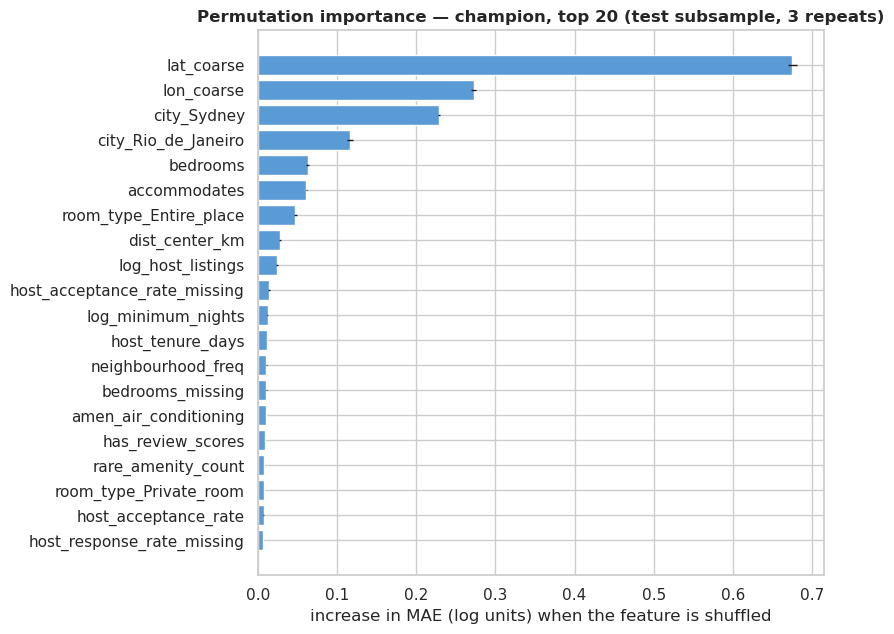

computed in 58s on 8,000 test rows
                     feature  importance      std
                  lat_coarse    0.675176 0.005938
                  lon_coarse    0.272699 0.003118
                 city_Sydney    0.228220 0.001249
         city_Rio_de_Janeiro    0.115918 0.003809
                    bedrooms    0.062657 0.001470
                accommodates    0.060915 0.000782
      room_type_Entire_place    0.047235 0.001514
              dist_center_km    0.027903 0.001187
           log_host_listings    0.023674 0.001171
host_acceptance_rate_missing    0.014159 0.001058

Rank agreement with the Step 7A screen of the same configuration (top-12): rho = 0.965
  (high rho = the refit did not change what the model relies on, only how well it fits)
                              screen (val, 80% fit)  champion (test, 100% fit)
lat_coarse                                   0.6965                     0.6752
city                                         0.3337                     0.3545
lo

In [27]:
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(RANDOM_STATE)
sub = rng.choice(len(X_test), 8000, replace=False)
t0 = time.time()
perm = permutation_importance(best_model, X_test.iloc[sub], y_test[sub],
                              scoring="neg_mean_absolute_error",
                              n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
pi = (pd.DataFrame({"feature": X_test.columns,
                    "importance": perm.importances_mean,
                    "std": perm.importances_std})
        .nlargest(20, "importance").sort_values("importance"))
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.barh(pi.feature, pi.importance, xerr=pi["std"], color="#5B9BD5", error_kw={"lw": 1})
ax.set_xlabel("increase in MAE (log units) when the feature is shuffled")
ax.set_title("Permutation importance — champion, top 20 (test subsample, 3 repeats)",
             fontweight="bold")
plt.tight_layout()
with mlflow.start_run(run_id=BEST_RUN_ID):
    log_fig(fig, "permutation_importance.png", subdir="error_analysis")
plt.show(); plt.close()
print(f"computed in {time.time()-t0:.0f}s on {len(sub):,} test rows")
print(pi.sort_values('importance', ascending=False).head(10).to_string(index=False))

# Consistency with the screening pass: the champion is a full-data refit of the
# winning candidate, so its reliance profile should closely track that candidate's.
# A large divergence would mean the extra 20% of training data changed what the
# model depends on -- worth knowing before the model card claims stability.
_champ_grouped = (pd.Series(perm.importances_mean, index=X_test.columns)
                    .groupby([_parent(c) for c in X_test.columns]).sum())
_cand_col = short(BEST_RUN_NAME_VAL)
if _cand_col in grouped.columns:
    cmp = pd.DataFrame({"screen (val, 80% fit)": grouped[_cand_col],
                        "champion (test, 100% fit)": _champ_grouped}).dropna()
    # Top-N head only, for the same reason as Step 7A: the near-zero tail ranks randomly.
    _head = cmp.loc[cmp.max(axis=1).nlargest(RANK_TOP_N).index]
    rho = _head.rank(ascending=False).corr(method="spearman").iloc[0, 1]
    print(f"\nRank agreement with the Step 7A screen of the same configuration "
          f"(top-{RANK_TOP_N}): rho = {rho:.3f}")
    print("  (high rho = the refit did not change what the model relies on, only how well "
          "it fits)")
    print(cmp.sort_values("champion (test, 100% fit)", ascending=False).head(10).round(4).to_string())

### 9.6 Forensics on the most extreme mispricings

The tail of the error distribution is where host trust is won or lost (the RMSE rationale, made concrete). Below: the **worst test-set mispricings by absolute log residual**, with the scaled features inverted back to human units using the Notebook 01 artifacts, followed by a check of **which segments are over-represented in the worst 1%** relative to their share of the test set.

In [28]:
SC = ARTS["scaler"]; s_idx = {c: i for i, c in enumerate(SC["columns"])}
unscale = lambda col: X_test[col].values * SC["scale"][s_idx[col]] + SC["mean"][s_idx[col]]

forensic = err.copy()
forensic["accommodates"]   = unscale("accommodates").round(0)
forensic["bedrooms"]       = unscale("bedrooms").round(0)
forensic["dist_center_km"] = unscale("dist_center_km").round(1)
forensic["amenities"]      = unscale("amenity_count").round(0)
forensic["ratio"]          = (forensic["price"] / forensic["pred_price"]).round(2)
forensic["ccy"]            = forensic["city"].map(CURRENCY)

worst = forensic.reindex(forensic["resid"].abs().sort_values(ascending=False).index).head(12)
cols = ["city", "ccy", "room_type", "accommodates", "bedrooms", "dist_center_km",
        "amenities", "price", "pred_price", "ratio", "resid"]
print("WORST 12 TEST-SET MISPRICINGS (ratio = actual / predicted)")
print(worst[cols].round({"pred_price": 0, "resid": 2}).to_string(index=False))

# Which segments crowd the worst 1%?
cut = forensic["resid"].abs().quantile(0.99)
w1 = forensic[forensic["resid"].abs() >= cut]
seg = pd.concat([
    (w1["city"].value_counts(normalize=True) / forensic["city"].value_counts(normalize=True)).rename("city lift"),
    (w1["room_type"].value_counts(normalize=True) / forensic["room_type"].value_counts(normalize=True)).rename("room-type lift"),
], axis=1)
print(f"\nOver-representation in the worst 1% (lift > 1 = segment fails more than its share):")
print(seg.round(2).fillna("").to_string())
over = (w1["resid"] > 0).mean() * 100
print(f"\nOf the worst 1%: {over:.0f}% are UNDER-predictions (actual far above suggestion) — "
      f"the luxury tail — and {100-over:.0f}% are over-predictions.")

WORST 12 TEST-SET MISPRICINGS (ratio = actual / predicted)
          city ccy    room_type  accommodates  bedrooms  dist_center_km  amenities  price  pred_price  ratio  resid
Rio de Janeiro BRL Private room           2.0       1.0       22.700001       11.0   5455        99.0  54.99   4.00
        Sydney AUD Private room           3.0       1.0       21.299999       25.0  15000        44.0 337.99   3.91
       Bangkok THB  Shared room           2.0       1.0        3.700000       12.0 100000       670.0 149.15   3.84
Rio de Janeiro BRL Private room           2.0       1.0       18.299999       17.0   5455       118.0  46.31   3.83
Rio de Janeiro BRL Entire place           3.0       1.0        1.100000       19.0  20000       243.0  82.15   3.71
        Sydney AUD Private room           2.0       1.0        3.800000       14.0  10000        55.0 183.37   3.70
     Hong Kong HKD Private room           1.0       1.0        2.900000       10.0  11644       246.0  47.30   3.70
       Bangko

**Diagnosis.** The forensic table is unambiguous and it is *not* the story one might expect. The worst mispricings are not exotic properties the model failed to understand. They are **implausible advertised rates on modest listings**: five- and six-figure local-currency prices on shared and private rooms, up to ~340× the model's suggestion (a Sydney private room advertised at A$15,000 against a suggested A$44; a Bangkok shared room at ฿100,000 against ฿670). With ~9 in 10 of the worst 1% being under-predictions and shared rooms over-represented ~3.8×, this is a **label-quality error mode, not a model error mode**: "de-listing prices" hosts park on calendars to block bookings, currency-scale typos, and aspirational placeholders — values that survived Notebook 01's Tier-1 validity checks precisely because a high price is not *impossible*, only implausible (the Tier-2/3 policy deliberately kept them, winsorising the *training* target while leaving raw *test* labels honest. The city lifts (Bangkok, Hong Kong, Rio, Istanbul at ~1.6–1.8×) map where the behaviour concentrates. What this buys Notebook 04: **(1)** plausibility screens as *features rather than filters* — a within-city × room-type price-per-person percentile lets the model and the product flag suspect labels instead of silently learning from them; **(2)** SHAP on this cohort to confirm the model priced the *features* correctly while the *label* was junk; **(3)** quantile-regression heads (P10/P90) so the product can show a fair-rate *range* and abstain when the interval is wide; **(4)** a model-card note that point suggestions are reliable for mainstream inventory, while extreme advertised rates get flagged for review rather than matched.

**Diagnosis: Label Quality vs. Model Error**

The forensic analysis of our worst mispricings reveals an unexpected truth: the model isn't failing to understand complex or exotic properties. Instead, the massive errors stem directly from **implausible advertised rates on highly modest listings**. We are seeing five- and six-figure local-currency prices attached to basic private and shared rooms, soaring up to ~340× higher than the model's suggested rate. For instance, a private room in Sydney was listed at A$15,000 (against a suggested A$44), and a shared room in Bangkok at ฿100,000 (against ฿670). 

With roughly 90% of the top 1% of errors being massive under-predictions, and shared rooms being over-represented by ~3.8×, this is undeniably a **label-quality issue rather than a model failure**. These extreme values are artifacts of host behavior: "de-listing" prices (parking an absurd rate to block out calendar dates), currency typos, and aspirational placeholder rates. These numbers survived Notebook 01's Tier-1 validity checks because a massive price is not *strictly impossible*, just highly improbable. Our methodology intentionally kept raw labels in the test set to measure honest real-world performance, while safely winsorizing the training targets. As expected, these extreme host behaviors heavily concentrate in specific markets, driving up the error multipliers in cities like Bangkok, Hong Kong, Rio, and Istanbul (~1.6–1.8×).

This diagnostic breakdown provides four clear directives for future improvements:

1.  **Plausibility as a Feature:** Instead of silently filtering out extreme prices, we will engineer features—such as a *within-city × room-type price-per-person percentile*—to help the model and the final product actively flag suspect rates rather than learning from them.
2.  **SHAP Validation:** We will apply SHAP to this specific cohort of extreme errors to prove that the model correctly evaluated the *property features*, even when the actual *target label* was junk data.
3.  **Quantile Regression:** We will introduce P10/P90 quantile regression heads. This enables the product to output a fair-rate *range* rather than a single point estimate, allowing the system to gracefully abstain or warn the user when the confidence interval is dangerously wide.
4.  **Model Card Documentation:** We will explicitly note in the model card that point predictions are highly reliable for mainstream inventory, but wildly out-of-bounds advertised rates should be flagged for human review rather than blindly matched.

## 10. Sanity Check — the Hand-off Artifact Works

Notebook 03's pipeline will consume `best_model.json` + the MLflow model URI, so this notebook ends by proving that path works: five test listings scored by the **reloaded** artifact, shown the way a host would read them, which is in local currency.

In [29]:
sample = err.sample(5, random_state=RANDOM_STATE)[["city", "price", "pred_price"]].copy()
sample["currency"]        = sample["city"].map(CURRENCY)
sample["suggested rate"]  = sample["pred_price"].round(0).astype(int)
sample["actual rate"]     = sample["price"].astype(int)
sample["abs % error"]     = (100 * (sample["pred_price"] - sample["price"]).abs() / sample["price"]).round(1)
print("Sample predictions from the best MLflow run model (fair ADVERTISED rate, local currency):")
print(sample[["city", "currency", "actual rate", "suggested rate", "abs % error"]].to_string(index=False))

Sample predictions from the best MLflow run model (fair ADVERTISED rate, local currency):
     city currency  actual rate  suggested rate  abs % error
Cape Town      ZAR          912            1054         15.6
    Paris      EUR           50              79         58.7
    Paris      EUR           70              62         11.6
 Istanbul      TRY          269             368         36.8
    Paris      EUR           59              57          4.0


In [30]:
print("=" * 60)
print("NOTEBOOK 02 COMPLETE")
print("=" * 60)
print(f"Experiment : {MLFLOW_EXPERIMENT}")
print(f"Tracking   : {MLFLOW_TRACKING_URI}")
print(f"Runs logged: ridge, random forest, hgb default, hgb tuning parent "
      f"(+{len(param_grid)} children), champion refit")
print()
print("Protocol")
print(f"  fit {len(X_fit):,} / validation {len(X_val):,} / test {len(X_test):,}")
print(f"  selected on val_mae_log across {len(runs)} candidates -> {short(BEST_RUN_NAME_VAL)}")
print(f"  refit on the full {len(X_train):,}-row training set -> {BEST_RUN_NAME}")
print(f"  test split read exactly once (audited in 8C)")
print()
print(f"Champion   : {BEST_RUN_NAME}  [{CHAMPION_CTOR.__name__}]")
print(f"  val_mae_log  {BEST_VAL_METRICS['val_mae_log']:.4f}  (selection)")
print(f"  test_mae_log {BEST_METRICS['test_mae_log']:.4f} | test_mape {BEST_METRICS['test_mape']:.1f}% | "
      f"test_r2_log {BEST_METRICS['test_r2_log']:.4f}  (reporting)")
print(f"Quality gate ({QUALITY_GATE_R2LOG} R2_log): {'PASSED' if GATE_PASSED else 'FAILED'}")
print(f"Hand-off   : best_model.json  ->  {BEST_MODEL_URI}")
print()
print("Next: Notebook 03 — orchestrate training + registration with SageMaker Pipelines,")
print("logging to the SAME SageMaker MLflow App ARN.")

NOTEBOOK 02 COMPLETE
Experiment : ITI113/team14/Experiment1
Tracking   : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Runs logged: ridge, random forest, hgb default, hgb tuning parent (+6 children), champion refit

Protocol
  fit 178,715 / validation 44,679 / test 55,849
  selected on val_mae_log across 4 candidates -> hgb (tuned)
  refit on the full 223,394-row training set -> team14_s1402_champion_refit
  test split read exactly once (audited in 8C)

Champion   : team14_s1402_champion_refit  [HistGradientBoostingRegressor]
  val_mae_log  0.3262  (selection)
  test_mae_log 0.3207 | test_mape 33.4% | test_r2_log 0.8708  (reporting)
Quality gate (0.65 R2_log): PASSED
Hand-off   : best_model.json  ->  runs:/3799806706b946aa88a316ffaa4eeb6d/model

Next: Notebook 03 — orchestrate training + registration with SageMaker Pipelines,
logging to the SAME SageMaker MLflow App ARN.


---
## Checklist before Notebook 03

- [ ] MLflow App config discovered (or `DEFAULT_MLFLOW_APP_ARN` verified)
- [ ] MLflow App tag `TeamId` matches notebook `TEAM_ID` (or LOCAL_MODE noted)
- [ ] **Fit/validation split created, city-stratified, sizes printed**
- [ ] Ridge baseline logged — coefficients reviewed against Notebook 01 EDA
- [ ] Random Forest and Hist Gradient Boosting runs logged with identical metric suite
- [ ] Tuning parent + nested child runs visible in the MLflow UI (CV on the **fit** split)
- [ ] All four metrics (MAE, RMSE, R², MAPE) logged as `fit_*` / `val_*` for every candidate
- [ ] **Step 7A screening pass reviewed: no leakage suspect, ensembles agree on feature ranks, geography used**
- [ ] **Selection made on `val_mae_log`; no candidate run carries a test metric**
- [ ] **Step 8B champion refit on the full training set; model verified loadable**
- [ ] **Step 8C protocol audit passed: exactly one run holds test metrics, and it is the champion**
- [ ] Quality gate evaluated (test R²_log ≥ 0.65) and result recorded
- [ ] `BEST_RUN_ID` / `BEST_MODEL_URI` recorded; model reloads and predicts
- [ ] `best_model.json` written with tracking, gate, hyperparameters and `validation_protocol`
- [ ] Error analysis reviewed: calibration, residuals, per-city table, price-band bias,
      permutation importance, extreme-error forensics (all logged under `error_analysis/`)
- [ ] Per-city table and `validation_protocol` carried into the model card

→ Continue to Notebook 03 to orchestrate training, model registration and deployment with SageMaker Pipelines.

## Download the best model if needed

Standalone cell (mirrors the reference notebook): reads `best_model.json`, reconnects to the same tracking target, reloads the model, and downloads the raw artifact folder — useful for packaging the model outside MLflow.

In [31]:
BEST_MODEL_JSON = "best_model.json"
if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(f"{BEST_MODEL_JSON} not found. Run the model selection cells first.")
info = json.loads(Path(BEST_MODEL_JSON).read_text())

mlflow.set_tracking_uri(info["mlflow_tracking_uri"])
reloaded = mlflow.sklearn.load_model(info["best_model_uri"])
print(f"Reloaded {type(reloaded).__name__} from {info['best_model_uri']}")

dst = Path("downloaded_model"); dst.mkdir(exist_ok=True)
local_path = mlflow.artifacts.download_artifacts(
    run_id=info["best_run_id"], artifact_path="model", dst_path=str(dst))
print("Model artifact downloaded to:", local_path)
for p in sorted(Path(local_path).rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(dst.resolve()), f"({p.stat().st_size/1024:.0f} KB)")

Reloaded HistGradientBoostingRegressor from runs:/3799806706b946aa88a316ffaa4eeb6d/model


Model artifact downloaded to: /home/sagemaker-user/HSAssignment/HoiSingAssignment/downloaded_model/model/
   model/MLmodel (7 KB)
   model/conda.yaml (0 KB)
   model/input_example.json (3 KB)
   model/model.pkl (4218 KB)
   model/model.skops (5380 KB)
   model/python_env.yaml (0 KB)
   model/registered_model_meta (0 KB)
   model/requirements.txt (0 KB)
   model/serving_input_example.json (5 KB)
